In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm.auto import tqdm
from joblib import Parallel, delayed

mpl.rcParams.update({
    'font.size': 10, 'axes.labelsize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 8, 'lines.linewidth': 1.5,
})

/Users/vkfokina/PycharmProjects/FDR/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Single-stage FDR methods

We compare four methods that operate on the max-score $F(t) = \max_k F_K(t)[k]$:
- **$FDP_{GT}$** — ground truth (oracle, uses true $Y_t$)
- **$FDP_{KO}$** — T-TDC: (1+ $D^-(s)) / D^+(s)$, where $D^+$ = target winners, $D^-$ = decoy winners
- **$FDP_{KI}$** — C-TDC: $(1 + 2D^-) / (D^+ + D^-)$
- **$FDP_{MM}$** — Mix-Max: estimates FP directly from score distributions

Validation null $\tilde{V}_0^k$ is drawn from $\mathcal{N}(0,1)$ (Assumption 3: $V_0^k = T_0^k$).


In [2]:
#  Single-stage q-value functions

def compute_gt_qvalues(F_score, is_correct):
    """GT q-values from max-score and true labels."""
    N = len(F_score)
    desc = np.argsort(-F_score)
    tp_cum = np.cumsum(is_correct[desc])
    fdp = (np.arange(1, N + 1) - tp_cum) / np.arange(1, N + 1)
    q_sorted = np.minimum.accumulate(fdp[::-1])[::-1]
    q = np.empty(N)
    q[desc] = q_sorted
    return q


def compute_ko_qvalues(F_KO_score, target_wins):
    """T-TDC q-values: FDP_KO = 1+ D^- / D^+."""
    N = len(F_KO_score)
    desc = np.argsort(-F_KO_score)
    tw_cum = np.cumsum(target_wins[desc])
    kw_cum = np.cumsum(~target_wins[desc])
    fdp = (1 + kw_cum) / np.maximum(tw_cum, 1)
    q_sorted = np.minimum.accumulate(fdp[::-1])[::-1]
    q = np.full(N, np.inf)
    tw_mask = target_wins[desc]
    q[desc[tw_mask]] = q_sorted[np.where(tw_mask)[0]]
    return q


def compute_ki_qvalues(F_KO_score, target_wins):
    """C-TDC q-values: FDP_KI = (1 + 2*D^-) / total."""
    N = len(F_KO_score)
    desc = np.argsort(-F_KO_score)
    kw_cum = np.cumsum(~target_wins[desc])
    fdp = (1 + 2 * kw_cum) / np.arange(1, N + 1)
    q_sorted = np.minimum.accumulate(fdp[::-1])[::-1]
    q = np.empty(N)
    q[desc] = q_sorted
    return q


def compute_mm_qvalues(F_score, G_score):
    """Mix-Max q-values (Eq. 18-19)."""
    N = len(F_score)
    G_sorted = np.sort(G_score)
    counts = N - np.searchsorted(G_sorted, F_score, side='right')
    p = (1 + counts) / (N + 1)
    pi0 = min((1 + np.sum(p >= 0.8)) / (N * 0.8), 1.0)

    W_asc = np.sort(F_score)
    Z_asc = np.sort(G_score)
    rank_w = np.searchsorted(W_asc, Z_asc, side='right').astype(float)
    rank_z = np.arange(1, N + 1, dtype=float)
    h = np.clip(rank_w / ((1 - pi0) * rank_z) - pi0 / (1 - pi0), 0, 1)
    h_rcum = np.zeros(N + 1)
    h_rcum[:N] = np.cumsum(h[::-1])[::-1]

    desc = np.argsort(-F_score)
    z_start = np.searchsorted(Z_asc, F_score[desc], side='right')
    fp = pi0 * (N - z_start) + (1 - pi0) * h_rcum[z_start]
    fdp = fp / np.arange(1, N + 1, dtype=float)
    q_sorted = np.minimum.accumulate(fdp[::-1])[::-1]
    q = np.empty(N)
    q[desc] = q_sorted
    return q

### Data generation

$|T| = 100{,}000$ samples, $K \in \{3, 10, 30, 100\}$. 
50% null ($Y_t = 0$, all logits $\sim \mathcal{N}(0,1)$), 
50% signal (true-class logit $\sim \mathcal{N}(3,1)$, rest $\sim \mathcal{N}(0,1)$). 
Signal allocation: $n_k \propto 1/k^{1.3} + 0.02$ (power-law with floor).

In [3]:
# Data generation + simulation

N = 100_000
null_frac = 0.5
mu_signal = 3.0
sigma = 1.0
N_null = int(N * null_frac)
N_signal = N - N_null
N_REPS = 100
K_values = [3, 10, 30, 100]
q_thresholds = np.linspace(0, 1.0, 1001)

print(f'N = {N:,}, N_signal = {N_signal:,}, N_null = {N_null:,}, reps = {N_REPS}')
for K_val in K_values:
    weights = 1.0 / np.arange(1, K_val + 1) ** 1.3 + 0.02
    weights /= weights.sum()
    spc = np.round(N_signal * weights).astype(int)
    spc[0] += N_signal - spc.sum()
    pi0 = 1.0 - spc / N
    preview = ', '.join(str(x) for x in spc[:5])
    if K_val > 5:
        preview += ', ...'
    print(f'  K={K_val:>3}: [{preview}], '
          f'pi0_1={pi0[0]:.3f}, pi0_{K_val}={pi0[-1]:.4f}')

N = 100,000, N_signal = 50,000, N_null = 50,000, reps = 100
  K=  3: [29897, 12490, 7613], pi0_1=0.701, pi0_3=0.9239
  K= 10: [20517, 8571, 5224, 3720, 2884, ...], pi0_1=0.795, pi0_10=0.9859
  K= 30: [15284, 6386, 3893, 2772, 2149, ...], pi0_1=0.847, pi0_30=0.9952
  K=100: [10009, 4181, 2549, 1815, 1407, ...], pi0_1=0.900, pi0_100=0.9978


### Run simulation (100 reps)

In [6]:
def run_simulation(K_val, spc, seed):
    rng = np.random.default_rng(seed)

    Y = np.zeros(N, dtype=int)
    offset = N_null
    for k in range(K_val):
        Y[offset:offset + spc[k]] = k + 1
        offset += spc[k]
    rng.shuffle(Y)

    logits = rng.standard_normal((N, K_val))
    sig_idx = np.where(Y > 0)[0]
    logits[sig_idx, Y[sig_idx] - 1] += mu_signal

    F_score = np.max(logits, axis=1)
    L_pred = np.argmax(logits, axis=1) + 1
    is_correct = (Y > 0) & (Y == L_pred)

    decoy_logits = rng.standard_normal((N, K_val))
    G_score = np.max(decoy_logits, axis=1)
    target_wins = F_score > G_score
    F_KO_score = np.maximum(F_score, G_score)

    q_gt = compute_gt_qvalues(F_score, is_correct)
    q_ko = compute_ko_qvalues(F_KO_score, target_wins)
    q_ki = compute_ki_qvalues(F_KO_score, target_wins)
    q_mm = compute_mm_qvalues(F_score, G_score)

    return q_gt, q_ko, q_ki, q_mm, is_correct


def compute_power(q_values, is_correct, thresholds):
    q_corr = np.sort(q_values[is_correct & np.isfinite(q_values)])
    return np.searchsorted(q_corr, thresholds, side='right') / N_signal


results = {}
for K_val in K_values:
    weights = 1.0 / np.arange(1, K_val + 1) ** 1.3 + 0.02
    weights /= weights.sum()
    spc = np.round(N_signal * weights).astype(int)
    spc[0] += N_signal - spc.sum()

    pw = {f'{m}_power': np.empty((N_REPS, len(q_thresholds)))
          for m in ('gt', 'ko', 'ki', 'mm')}

    for rep in tqdm(range(N_REPS), desc=f'K={K_val}'):
        seed = 42 * 1000 + K_val * 100 + rep
        q_gt, q_ko, q_ki, q_mm, ic = run_simulation(K_val, spc, seed)
        for key, qv in [('gt', q_gt), ('ko', q_ko), ('ki', q_ki), ('mm', q_mm)]:
            pw[f'{key}_power'][rep] = compute_power(qv, ic, q_thresholds)

    results[K_val] = pw
    print(f'K={K_val} done.')

print('All simulations complete.')

K=3: 100%|██████████| 100/100 [00:06<00:00, 16.10it/s]


K=3 done.


K=10: 100%|██████████| 100/100 [00:06<00:00, 14.47it/s]


K=10 done.


K=30: 100%|██████████| 100/100 [00:09<00:00, 10.94it/s]


K=30 done.


K=100: 100%|██████████| 100/100 [00:16<00:00,  5.95it/s]

K=100 done.
All simulations complete.


### Power curves

Statistical power = $TP(\alpha) / N_{signal}$ as a function of FDR threshold. 
100 curves overlaid (opacity 0.05) — low variance confirms stable results.

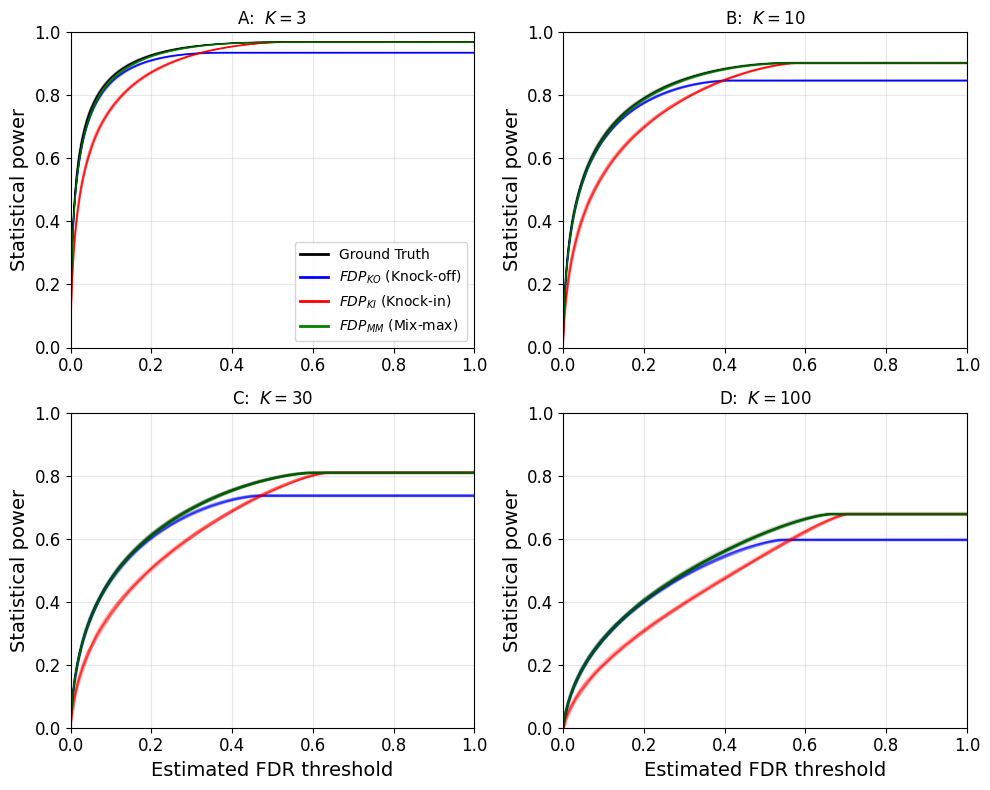

In [53]:
# Power grid plot

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
panel_labels = ['A', 'B', 'C', 'D']

for idx, K_val in enumerate(K_values):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    res = results[K_val]

    for m, color in [('gt', 'k'), ('ko', 'b'), ('ki', 'r'), ('mm', 'g')]:
        for rep in range(N_REPS):
            ax.plot(q_thresholds, res[f'{m}_power'][rep], color, alpha=0.05, lw=0.5)

    ax.set_title(f'{panel_labels[idx]}:  $K = {K_val}$', fontsize=12)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3)
    if row == 1:
        ax.set_xlabel('Estimated FDR threshold')
    ax.set_ylabel('Statistical power')

axes[0, 0].plot([], [], 'k-', lw=2, label='Ground Truth')
axes[0, 0].plot([], [], 'b-', lw=2, label=r'$FDP_{KO}$ (Knock-off)')
axes[0, 0].plot([], [], 'r-', lw=2, label=r'$FDP_{KI}$ (Knock-in)')
axes[0, 0].plot([], [], 'g-', lw=2, label=r'$FDP_{MM}$ (Mix-max)')
axes[0, 0].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('figures/power_grid_100curves.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Cascaded FDR (Alg. 2)

Instead of a single max-score competition, we process classes sequentially:
1. Estimate $\hat\pi_0^k$ for each class (Storey for BH, target-decoy ratio for KO)
2. Filter out classes with $\hat\pi_0^k \approx 1$ (no signal)
3. Order remaining classes by ascending $\hat\pi_0^k$ (most signal first)
4. At each stage: compute per-class q-values, sequester discoveries ($q_t < \alpha$)
5. Stop if $|R| < 1/\alpha$ (minimum-rejection rule)

Per-class FDR estimation uses $FDP_{KO}^k$ (Eq. 15) or $FDP_{BH}$ (Eq. 4)
with empirical p-values from validation null $\tilde{V}_0^k$.

In [4]:
# Per-class helpers (used inside the cascade)

def storey_pi0(p, lam=0.8):
    n = len(p)
    return min((1 + np.sum(p >= lam)) / (n * (1 - lam)), 1.0)

def ko_pi0(logits, decoys):
    w = np.mean(logits > decoys)
    return max(min(2.0 * (1.0 - w), 1.0), 0.0)

def gt_qvalues(scores, is_tp):
    n = len(scores)
    desc = np.argsort(-scores)
    tp_cum = np.cumsum(is_tp[desc])
    fdp = (np.arange(1, n + 1) - tp_cum) / np.arange(1, n + 1)
    q = np.empty(n)
    q[desc] = np.minimum.accumulate(fdp[::-1])[::-1]
    return q

def bh_qvalues(pvals):
    n = len(pvals)
    pi0 = storey_pi0(pvals)
    idx = np.argsort(pvals)
    fdp = n * pi0 * pvals[idx] / np.arange(1, n + 1)
    q_sorted = np.minimum(np.minimum.accumulate(fdp[::-1])[::-1], 1.0)
    q = np.empty(n)
    q[idx] = q_sorted
    return q

def ko_qvalues_perclass(logits, decoys):
    n = len(logits)
    wins = logits > decoys
    desc = np.argsort(-np.maximum(logits, decoys))
    tw = np.cumsum(wins[desc])
    kw = np.cumsum(~wins[desc])
    fdp = (1 + kw) / np.maximum(tw, 1)
    q_sorted = np.minimum.accumulate(fdp[::-1])[::-1]
    q = np.full(n, np.inf)
    mask = wins[desc]
    q[desc[mask]] = q_sorted[np.where(mask)[0]]
    return q

In [5]:
# Cascade procedures

def cascade_final(data, decoys, Y, alpha, method, pi0_tol=0.001):
    """Cascade FDR: pi0 filter + ascending order + min-rejection stopping."""
    N, K = data.shape
    if method == 'ko':
        pi0 = np.array([ko_pi0(data[:, k], decoys[:, k]) for k in range(K)])
    else:
        pi0 = np.array([storey_pi0(data[:, k]) for k in range(K)])
    keep = pi0 < 1.0 - pi0_tol
    order = np.where(keep)[0]
    order = order[np.argsort(pi0[order])]
    remaining = np.ones(N, dtype=bool)
    q_out = np.full(N, np.inf)
    ic_out = np.zeros(N, dtype=bool)
    min_rej = 1.0 / alpha
    for k in order:
        idx = np.where(remaining)[0]
        if len(idx) == 0:
            break
        if method == 'ko':
            q = ko_qvalues_perclass(data[idx, k], decoys[idx, k])
        else:
            q = bh_qvalues(data[idx, k])
        disc = q < alpha
        if int(disc.sum()) < min_rej:
            break
        disc_idx = idx[disc]
        q_out[disc_idx] = q[disc]
        ic_out[disc_idx] = (Y[disc_idx] == k + 1)
        remaining[disc_idx] = False
    return q_out, ic_out


def cascade_final_gt(data, decoys, Y, alpha, pi0_tol=0.001):
    """Cascade with oracle q-values + pi0 filter + min-rejection stopping."""
    N, K = data.shape
    true_pi = np.array([1.0 - np.mean(Y == k + 1) for k in range(K)])
    keep = true_pi < 1.0 - pi0_tol
    order = np.where(keep)[0]
    order = order[np.argsort(true_pi[order])]
    remaining = np.ones(N, dtype=bool)
    q_out = np.full(N, np.inf)
    ic_out = np.zeros(N, dtype=bool)
    min_rej = 1.0 / alpha
    for k in order:
        idx = np.where(remaining)[0]
        if len(idx) == 0:
            break
        is_tp = (Y[idx] == k + 1)
        q = gt_qvalues(data[idx, k], is_tp)
        disc = q < alpha
        if int(disc.sum()) < min_rej:
            break
        disc_idx = idx[disc]
        q_out[disc_idx] = q[disc]
        ic_out[disc_idx] = is_tp[disc]
        remaining[disc_idx] = False
    return q_out, ic_out


def empirical_pvalues(logits, rng, M):
    """Empirical p-values from M null scores ~ N(0,1)."""
    null_scores = np.sort(rng.standard_normal(M))
    ranks = np.searchsorted(null_scores, logits, side='left')
    return (M - ranks + 1) / (M + 1)

### Pure null experiment

All $Y_t = 0$, so any rejection is a false discovery.
We report $P(\text{any rejection})$ over 100 reps — must stay $\leq \alpha$.

BH uses **empirical p-values** from $M = |T|/\alpha_{\min}$ validation null scores.

In [56]:
REPS_NULL_C = 100
N_NULL_C = 100_000
K_LIST_C = [10, 30, 100]
ALPHAS_C = [0.01, 0.05, 0.10, 0.20, 0.50]
M_NULL_C = int(N_NULL_C / min(ALPHAS_C))  # = 10,000,000
METHODS_C = ['Single-stage GT', 'Cascade GT', 'Cascade KO', 'Cascade BH']

print(f'Validation null size: M = {M_NULL_C:,}')

def run_null_cascade_rep(K, seed):
    rng = np.random.default_rng(seed)
    L = rng.standard_normal((N_NULL_C, K))
    D = rng.standard_normal((N_NULL_C, K))
    Y = np.zeros(N_NULL_C, dtype=int)

    # Empirical p-values for BH (under null: logits ~ N(0,1))
    P = empirical_pvalues(L, rng, M_NULL_C)

    # Single-stage GT
    best_k = np.argmax(L, axis=1)
    q_ss = compute_gt_qvalues(L[np.arange(N_NULL_C), best_k],
                              np.zeros(N_NULL_C, dtype=bool))

    out = {}
    for a in ALPHAS_C:
        q_gt, _ = cascade_final_gt(L, D, Y, a)
        res = {
            'Single-stage GT': q_ss,
            'Cascade GT':      q_gt,
            'Cascade KO':      cascade_final(L, D, Y, a, 'ko')[0],
            'Cascade BH':      cascade_final(P, D, Y, a, 'bh')[0],
        }
        for m in METHODS_C:
            out[(m, a)] = int(np.sum(res[m] < a) > 0)
    return out

null_c = {K: {m: {a: 0 for a in ALPHAS_C} for m in METHODS_C} for K in K_LIST_C}

for K in K_LIST_C:
    seeds = [42 * 1000 + K * 100 + r for r in range(REPS_NULL_C)]
    res_list = Parallel(n_jobs=3)(
        delayed(run_null_cascade_rep)(K, s)
        for s in tqdm(seeds, desc=f'Null K={K}'))
    for out in res_list:
        for m in METHODS_C:
            for a in ALPHAS_C:
                null_c[K][m][a] += out[(m, a)]

print('\n=== P(any false rejection) ===')
print(f'{"K":>5}  {"Method":<22}  ' +
      '  '.join(f'a={a}' for a in ALPHAS_C))
print('=' * 80)
for K in K_LIST_C:
    for m in METHODS_C:
        vals = '  '.join(
            f'{null_c[K][m][a]/REPS_NULL_C:.2f}' for a in ALPHAS_C)
        print(f'{K:>5}  {m:<22}  {vals}')
    print()

Validation null size: M = 10,000,000


Null K=30:   6%|▌         | 6/100 [00:03<01:01,  1.54it/s]/Users/vkfokina/PycharmProjects/FDR/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Null K=100: 100%|██████████| 100/100 [06:17<00:00,  3.78s/it]



=== P(any false rejection) ===
    K  Method                  a=0.01  a=0.05  a=0.1  a=0.2  a=0.5
   10  Single-stage GT         0.00  0.00  0.00  0.00  0.00
   10  Cascade GT              0.00  0.00  0.00  0.00  0.00
   10  Cascade KO              0.00  0.00  0.00  0.03  0.27
   10  Cascade BH              0.00  0.00  0.00  0.00  0.32

   30  Single-stage GT         0.00  0.00  0.00  0.00  0.00
   30  Cascade GT              0.00  0.00  0.00  0.00  0.00
   30  Cascade KO              0.00  0.00  0.00  0.03  0.21
   30  Cascade BH              0.00  0.00  0.00  0.00  0.34

  100  Single-stage GT         0.00  0.00  0.00  0.00  0.00
  100  Cascade GT              0.00  0.00  0.00  0.00  0.00
  100  Cascade KO              0.00  0.00  0.00  0.02  0.25
  100  Cascade BH              0.00  0.00  0.00  0.00  0.36



### Signal experiment (empirical p-values)

Same data generation as single-stage ($n_k \propto 1/k^{1.3} + 0.02$, $\mu=3$),
but now we compare single-stage GT vs three **cascaded** methods.
BH uses empirical p-values from $M = |T|/\alpha_{\min}$ validation null scores.

In [57]:
REPS_SIG_C = 100
N_SIG_C = 100_000
ALPHAS_SIG_C = [0.01, 0.05, 0.10, 0.20]
TH_C = np.linspace(0, 0.3, 500)
METHODS_SIG_C = ['Single-stage GT', 'Cascade GT', 'Cascade KO', 'Cascade BH']
M_SIG_C = int(N_SIG_C / min(ALPHAS_SIG_C))  # = 10,000,000

print(f'M = {M_SIG_C:,} validation null scores')

def generate_signal_data_v2(rng, N, K, null_frac=0.5, mu=3.0):
    n_null = int(N * null_frac)
    n_signal = N - n_null
    weights = 1.0 / np.arange(1, K + 1) ** 1.3 + 0.02
    weights /= weights.sum()
    counts = np.round(weights * n_signal).astype(int)
    counts[0] += n_signal - counts.sum()
    Y = np.zeros(N, dtype=int)
    pos = n_null
    for k in range(K):
        if counts[k] > 0:
            Y[pos:pos + counts[k]] = k + 1
            pos += counts[k]
    rng.shuffle(Y)
    logits = rng.standard_normal((N, K))
    sig_idx = np.where(Y > 0)[0]
    logits[sig_idx, Y[sig_idx] - 1] += mu
    decoys = rng.standard_normal((N, K))
    return logits, decoys, Y, n_signal


def compute_power_curve(q_values, is_correct, thresholds, n_signal):
    q_corr = np.sort(q_values[is_correct & np.isfinite(q_values)])
    return np.searchsorted(q_corr, thresholds, side='right') / n_signal


def run_signal_cascade_rep(K, seed):
    rng = np.random.default_rng(seed)
    logits, decoys, Y, n_sig = generate_signal_data_v2(rng, N_SIG_C, K)
    pvals = empirical_pvalues(logits, rng, M_SIG_C)
    N_ = len(Y)
    best_k = np.argmax(logits, axis=1)
    best_s = logits[np.arange(N_), best_k]
    is_tp_ss = (Y > 0) & (best_k == Y - 1)
    q_ss = compute_gt_qvalues(best_s, is_tp_ss)

    out = {}
    for a in ALPHAS_SIG_C:
        q_gt, ic_gt = cascade_final_gt(logits, decoys, Y, a)
        q_ko, ic_ko = cascade_final(logits, decoys, Y, a, 'ko')
        q_bh, ic_bh = cascade_final(pvals, decoys, Y, a, 'bh')

        res = {
            'Single-stage GT': (q_ss, is_tp_ss),
            'Cascade GT':      (q_gt, ic_gt),
            'Cascade KO':      (q_ko, ic_ko),
            'Cascade BH':      (q_bh, ic_bh),
        }
        for m in METHODS_SIG_C:
            q, ic = res[m]
            disc = q < a
            R = disc.sum()
            FP = (disc & ~ic).sum()
            TP = (disc & ic).sum()
            out[(m, a, 'fdr')] = FP / R if R > 0 else 0.0
            out[(m, a, 'pow')] = TP / n_sig
            out[(m, a, 'cur')] = compute_power_curve(q, ic, TH_C, n_sig)
    return out

fdr_c = {K: {m: {a: [] for a in ALPHAS_SIG_C} for m in METHODS_SIG_C} for K in K_LIST_C}
pow_c = {K: {m: {a: [] for a in ALPHAS_SIG_C} for m in METHODS_SIG_C} for K in K_LIST_C}
cur_c = {K: {m: {a: [] for a in ALPHAS_SIG_C} for m in METHODS_SIG_C} for K in K_LIST_C}

for K in K_LIST_C:
    seeds = [789 * 1000 + K * 100 + r for r in range(REPS_SIG_C)]
    res_list = Parallel(n_jobs=4)(
        delayed(run_signal_cascade_rep)(K, s)
        for s in tqdm(seeds, desc=f'Signal K={K}'))
    for out in res_list:
        for m in METHODS_SIG_C:
            for a in ALPHAS_SIG_C:
                fdr_c[K][m][a].append(out[(m, a, 'fdr')])
                pow_c[K][m][a].append(out[(m, a, 'pow')])
                cur_c[K][m][a].append(out[(m, a, 'cur')])

print(f'\nEmpirical p-values: M = {M_SIG_C:,}')
print('\n=== Mean FDR / Mean Power ===')
print(f'{"K":>5}  {"Method":<22}  {"a":>5}  {"FDR":>14}  {"Power":>14}')
print('-' * 70)
for K in K_LIST_C:
    for m in METHODS_SIG_C:
        for a in ALPHAS_SIG_C:
            fd = np.mean(fdr_c[K][m][a])
            pw = np.mean(pow_c[K][m][a])
            flag = ' *' if fd > a + 0.005 else ''
            print(f'{K:>5}  {m:<22}  {a:5.2f}  '
                  f'{fd:.4f}+-{np.std(fdr_c[K][m][a]):.4f}{flag}  '
                  f'{pw:.4f}+-{np.std(pow_c[K][m][a]):.4f}')
    print()

M = 10,000,000 validation null scores


Signal K=100: 100%|██████████| 100/100 [07:12<00:00,  4.33s/it]



Empirical p-values: M = 10,000,000

=== Mean FDR / Mean Power ===
    K  Method                      a             FDR           Power
----------------------------------------------------------------------
   10  Single-stage GT          0.01  0.0100+-0.0000  0.2746+-0.0132
   10  Single-stage GT          0.05  0.0500+-0.0000  0.5393+-0.0060
   10  Single-stage GT          0.10  0.1000+-0.0000  0.6684+-0.0041
   10  Single-stage GT          0.20  0.2000+-0.0000  0.7903+-0.0028
   10  Cascade GT               0.01  0.0098+-0.0001  0.3558+-0.0113
   10  Cascade GT               0.05  0.0499+-0.0000  0.6052+-0.0045
   10  Cascade GT               0.10  0.0999+-0.0000  0.7096+-0.0032
   10  Cascade GT               0.20  0.1999+-0.0000  0.7879+-0.0024
   10  Cascade KO               0.01  0.0091+-0.0011  0.3275+-0.0159
   10  Cascade KO               0.05  0.0469+-0.0017  0.5946+-0.0048
   10  Cascade KO               0.10  0.0953+-0.0022  0.7023+-0.0033
   10  Cascade KO               0.

### Power curves (cascade, empirical p-values)

Mean power $\pm$ std over 100 reps. Vertical line = nominal $\alpha$.

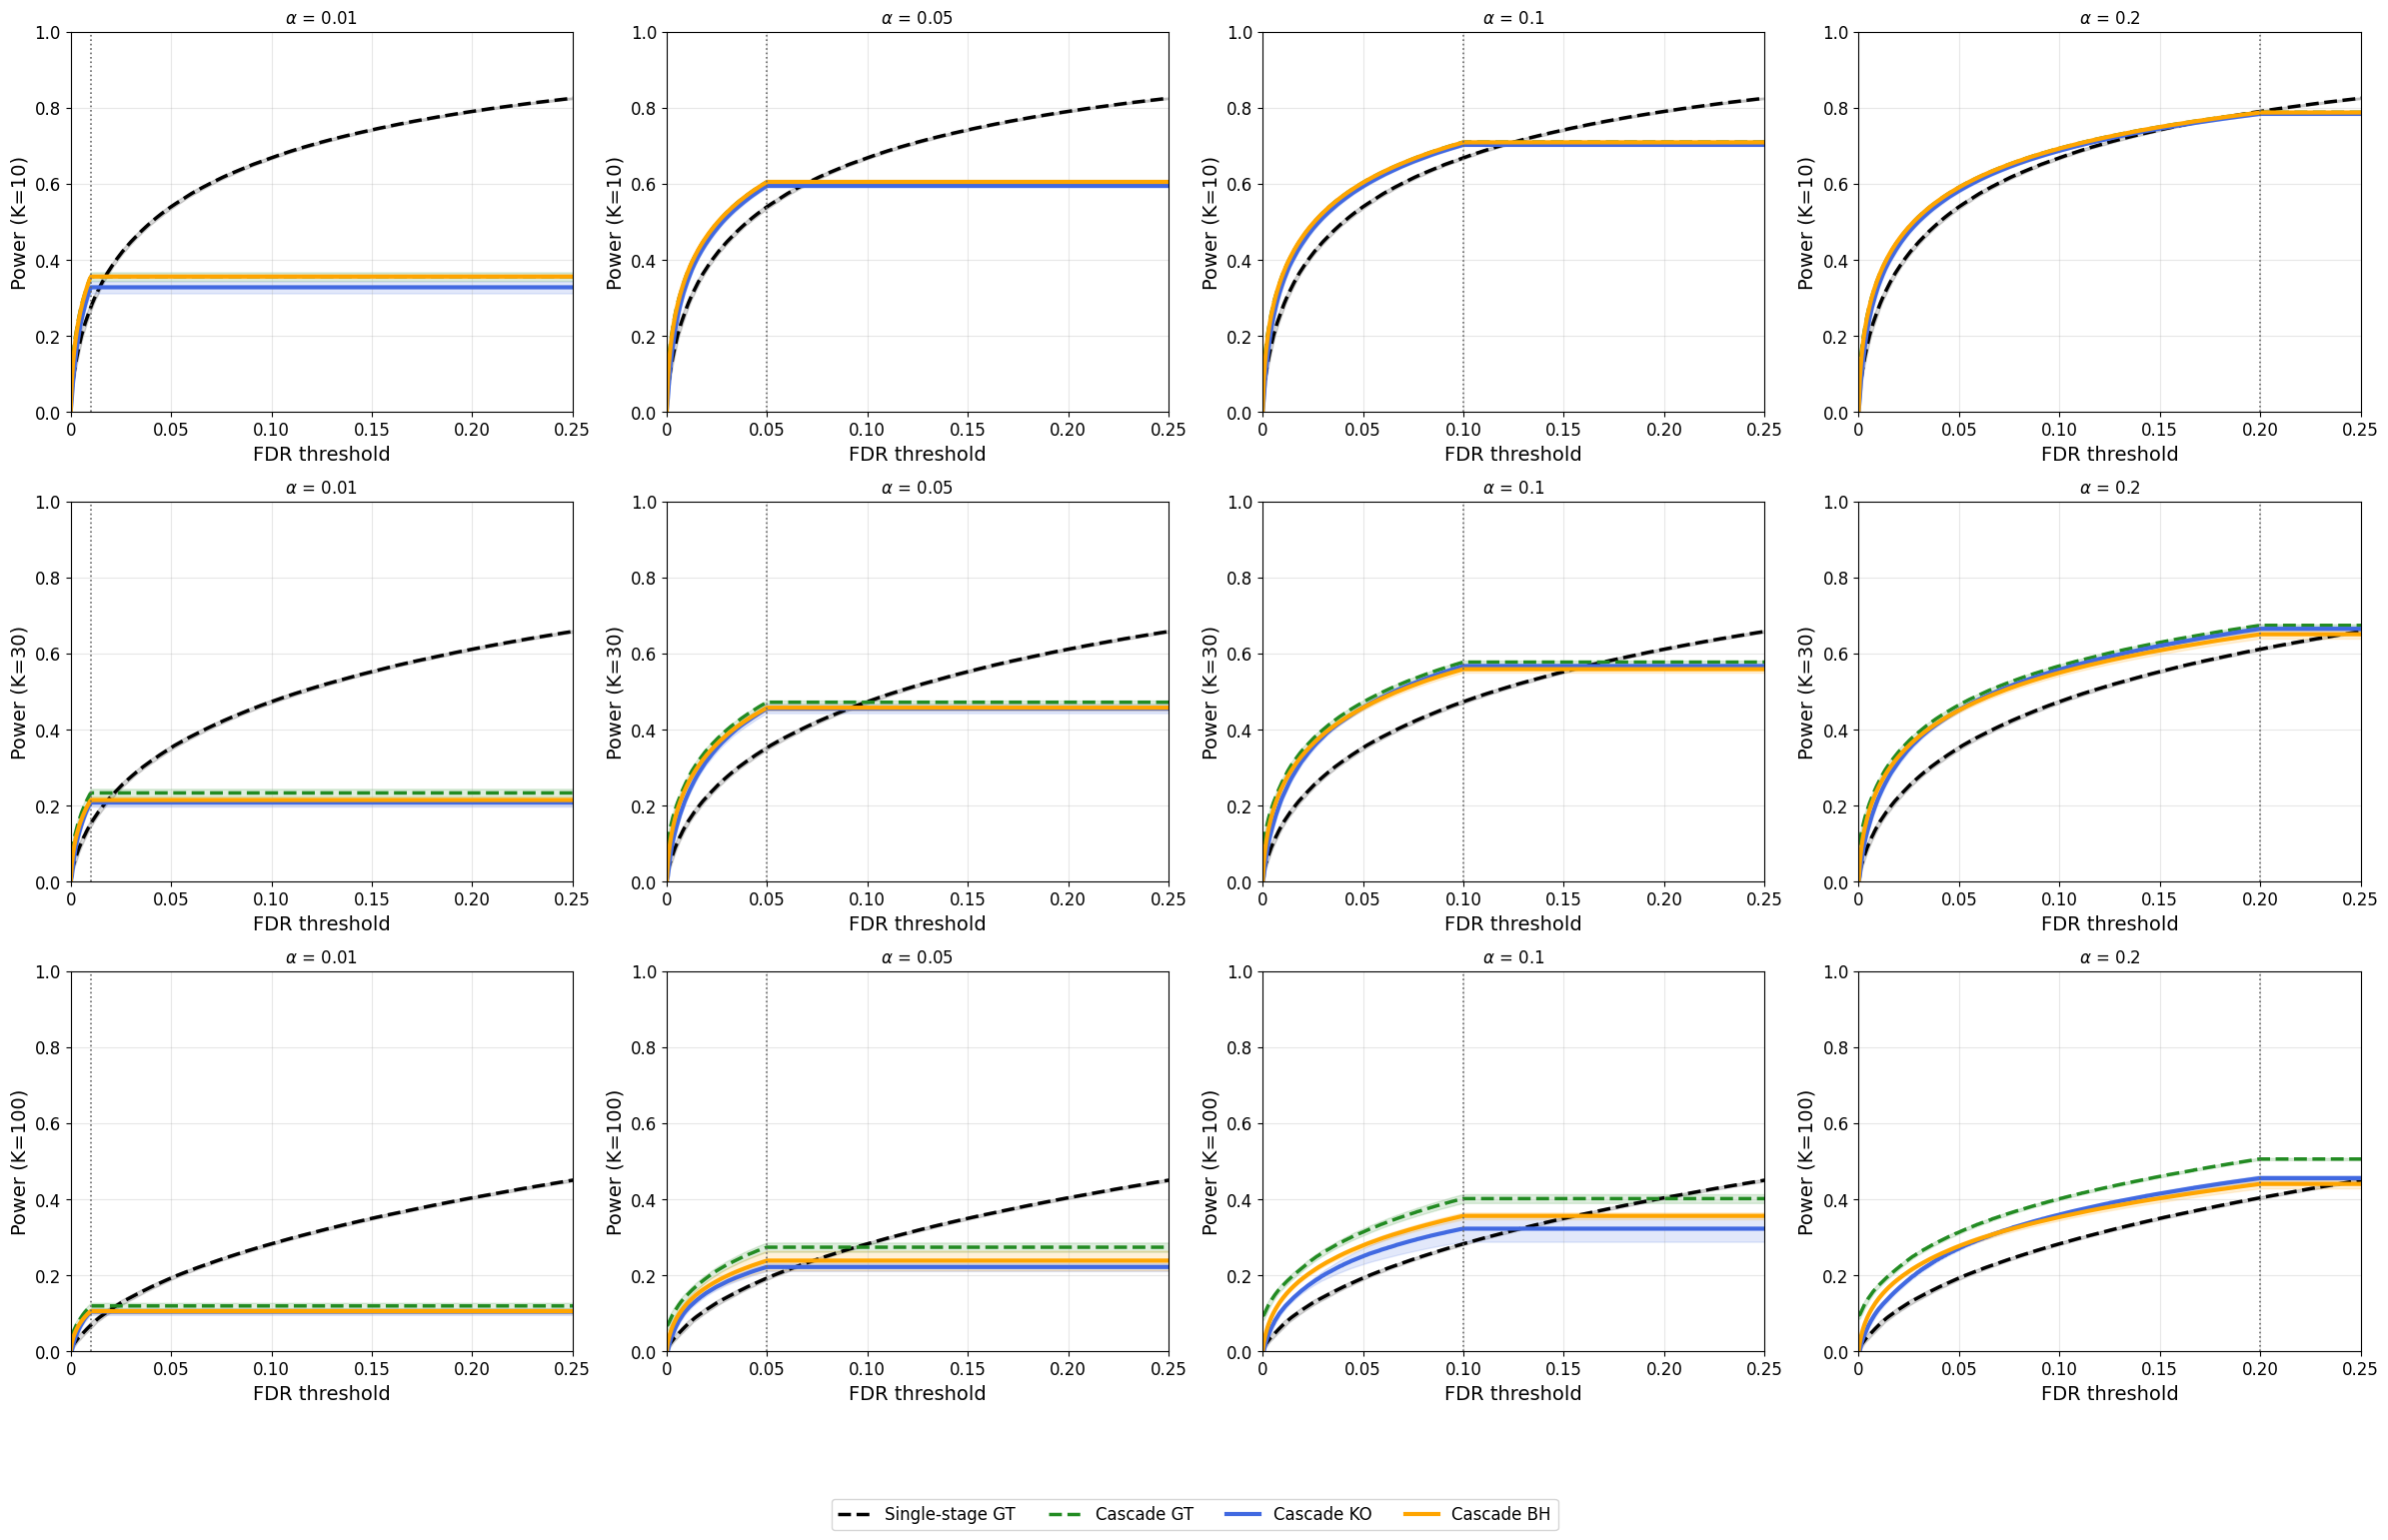

In [58]:
STYLES_C = {
    'Single-stage GT':  ('black',       '--', 2.5),
    'Cascade GT':       ('forestgreen', '--', 2.5),
    'Cascade KO':       ('royalblue',   '-',  3.0),
    'Cascade BH':       ('orange',      '-',  3.0),
}

fig, axes = plt.subplots(len(K_LIST_C), len(ALPHAS_SIG_C),
    figsize=(6 * len(ALPHAS_SIG_C), 5 * len(K_LIST_C)), squeeze=False)

for ri, K in enumerate(K_LIST_C):
    for ci, a in enumerate(ALPHAS_SIG_C):
        ax = axes[ri, ci]
        for m in METHODS_SIG_C:
            c, ls, lw = STYLES_C[m]
            arr = np.array(cur_c[K][m][a])
            mean = np.mean(arr, axis=0)
            std = np.std(arr, axis=0)
            ax.plot(TH_C, mean, color=c, ls=ls, lw=lw)
            ax.fill_between(TH_C, mean - std, mean + std,
                            color=c, alpha=0.15)
        ax.axvline(a, color='dimgray', ls=':', lw=1.2)
        ax.set_xlim(0, 0.25)
        ax.set_xticks([0, 0.05, 0.10, 0.15, 0.20, 0.25])
        ax.set_xticklabels(['0', '0.05', '0.10', '0.15', '0.20', '0.25'])
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3, linewidth=0.8)
        ax.set_xlabel('FDR threshold')
        ax.set_ylabel(f'Power (K={K})')
        ax.set_title(f'$\\alpha$ = {a}', fontsize=12)

handles = [plt.Line2D([], [], color=c, ls=ls, lw=lw, label=m)
           for m, (c, ls, lw) in STYLES_C.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=12,
           bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig('figures/cascade_power_empirical.pdf', bbox_inches='tight')
plt.show()

### Power vs FDR threshold: Cascade vs Single-stage (Fig. 4)

The cascade must be re-run at each $\alpha$ because sequestering depends on the threshold.
At low $\alpha$, the cascade benefits from per-class binary competition (higher power).
At high $\alpha$, early commitment to incorrect classes reduces power relative to single-stage.

In [13]:
# Power vs alpha: Cascade vs Single-stage

ALPHA_EC = np.linspace(0.005, 1.0, 100)
REPS_EC = 50
K_EC = [10, 30, 100]
M_EC = 10_000_000

def run_ec_rep(K, seed):
    rng = np.random.default_rng(seed)
    logits, decoys, Y, n_sig = generate_signal_data_v2(rng, 100_000, K)
    pvals = empirical_pvalues(logits, rng, M_EC)

    best_k = np.argmax(logits, axis=1)
    best_s = logits[np.arange(len(Y)), best_k]
    is_tp = (Y > 0) & (best_k == Y - 1)
    q_ss = compute_gt_qvalues(best_s, is_tp)
    q_corr = np.sort(q_ss[is_tp])
    pow_ss = np.searchsorted(q_corr, ALPHA_EC, side='right') / n_sig

    pow_cgt = np.empty(len(ALPHA_EC))
    pow_cko = np.empty(len(ALPHA_EC))
    pow_cbh = np.empty(len(ALPHA_EC))

    for i, a in enumerate(ALPHA_EC):
        _, ic = cascade_final_gt(logits, decoys, Y, a)
        pow_cgt[i] = ic.sum() / n_sig

        _, ic = cascade_final(logits, decoys, Y, a, 'ko')
        pow_cko[i] = ic.sum() / n_sig

        _, ic = cascade_final(pvals, decoys, Y, a, 'bh')
        pow_cbh[i] = ic.sum() / n_sig

    return pow_ss, pow_cgt, pow_cko, pow_cbh


ec_results = {}
for K in K_EC:
    seeds = [555_000 + K * 1000 + r for r in range(REPS_EC)]
    res_list = Parallel(n_jobs=4)(
        delayed(run_ec_rep)(K, s)
        for s in tqdm(seeds, desc=f'K={K}'))

    arrs = {m: [] for m in ['ss', 'cgt', 'cko', 'cbh']}
    for pw in res_list:
        for m, v in zip(['ss', 'cgt', 'cko', 'cbh'], pw):
            arrs[m].append(v)

    ec_results[K] = {m: np.array(v) for m, v in arrs.items()}
    print(f'K={K} done.')

print('All done.')



K=10:   0%|          | 0/50 [00:00<?, ?it/s]

K=10:  16%|█▌        | 8/50 [00:12<01:06,  1.58s/it]

K=10:  24%|██▍       | 12/50 [00:25<01:24,  2.22s/it]

K=10:  32%|███▏      | 16/50 [00:37<01:25,  2.52s/it]

K=10:  40%|████      | 20/50 [00:49<01:21,  2.70s/it]

K=10:  48%|████▊     | 24/50 [01:01<01:13,  2.84s/it]

K=10:  56%|█████▌    | 28/50 [01:14<01:04,  2.91s/it]

K=10:  64%|██████▍   | 32/50 [01:26<00:52,  2.94s/it]

K=10:  72%|███████▏  | 36/50 [01:38<00:41,  2.98s/it]

K=10:  80%|████████  | 40/50 [01:50<00:30,  3.00s/it]

K=10:  88%|████████▊ | 44/50 [02:02<00:18,  3.03s/it]

K=10: 100%|██████████| 50/50 [02:15<00:00,  2.70s/it]


K=10 done.




K=30:   0%|          | 0/50 [00:00<?, ?it/s]

K=30:  16%|█▌        | 8/50 [00:35<03:06,  4.43s/it]

K=30:  24%|██▍       | 12/50 [01:10<03:58,  6.27s/it]

K=30:  32%|███▏      | 16/50 [01:46<04:05,  7.22s/it]

K=30:  40%|████      | 20/50 [02:21<03:54,  7.82s/it]

K=30:  48%|████▊     | 24/50 [02:57<03:32,  8.16s/it]

K=30:  56%|█████▌    | 28/50 [03:33<03:05,  8.44s/it]

K=30:  64%|██████▍   | 32/50 [04:09<02:34,  8.61s/it]

K=30:  72%|███████▏  | 36/50 [04:44<02:01,  8.68s/it]

K=30:  80%|████████  | 40/50 [05:18<01:26,  8.62s/it]

K=30:  88%|████████▊ | 44/50 [05:53<00:51,  8.63s/it]

K=30: 100%|██████████| 50/50 [06:28<00:00,  7.77s/it]


K=30 done.




K=100:   0%|          | 0/50 [00:00<?, ?it/s]

K=100:  16%|█▌        | 8/50 [01:41<08:54, 12.72s/it]/Users/vkfokina/PycharmProjects/FDR/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


K=100:  24%|██▍       | 12/50 [03:27<11:41, 18.45s/it]

K=100:  32%|███▏      | 16/50 [05:10<12:00, 21.21s/it]

K=100:  40%|████      | 20/50 [07:00<11:40, 23.34s/it]

K=100:  48%|████▊     | 24/50 [08:41<10:24, 24.03s/it]

K=100:  56%|█████▌    | 28/50 [10:28<09:06, 24.84s/it]

K=100:  64%|██████▍   | 32/50 [12:17<07:40, 25.58s/it]

K=100:  72%|███████▏  | 36/50 [14:02<06:01, 25.84s/it]

K=100:  80%|████████  | 40/50 [15:47<04:19, 25.99s/it]

K=100:  88%|████████▊ | 44/50 [17:36<02:37, 26.32s/it]

K=100: 100%|██████████| 50/50 [19:29<00:00, 23.39s/it]


K=100 done.
All done.


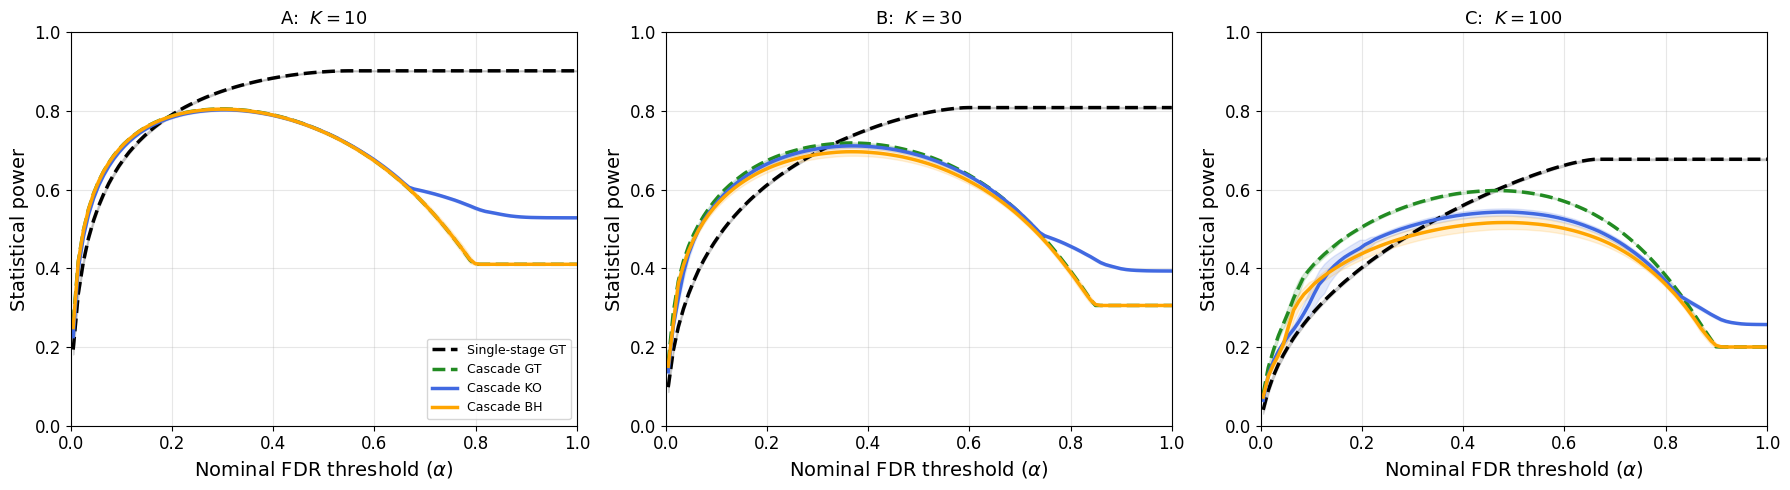

Saved to figures/cascaded_vs_standard_K10.pdf


In [14]:
# Plot: Power vs alpha (3 panels for K=10, 30, 100)

EC_COLORS = {'ss': 'black', 'cgt': 'forestgreen', 'cko': 'royalblue', 'cbh': 'orange'}
EC_LS = {'ss': '--', 'cgt': '--', 'cko': '-', 'cbh': '-'}
EC_LABELS = {
    'ss': 'Single-stage GT', 'cgt': 'Cascade GT',
    'cko': 'Cascade KO', 'cbh': 'Cascade BH',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
panel_labels = ['A', 'B', 'C']

for idx, K in enumerate(K_EC):
    ax = axes[idx]
    res = ec_results[K]

    for m in ['ss', 'cgt', 'cko', 'cbh']:
        c = EC_COLORS[m]
        ls = EC_LS[m]
        arr = np.array(res[m])
        mean = arr.mean(axis=0)
        std = arr.std(axis=0)
        ax.plot(ALPHA_EC, mean, color=c, ls=ls, lw=2.5)
        ax.fill_between(ALPHA_EC, mean - std, mean + std, color=c, alpha=0.15)
        ax.plot([], [], color=c, ls=ls, lw=2.5, label=EC_LABELS[m])

    ax.set_title(f'{panel_labels[idx]}:  $K = {K}$', fontsize=13)
    ax.set_xlabel('Nominal FDR threshold ($\\alpha$)')
    ax.set_ylabel('Statistical power')
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3)

axes[0].legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('figures/cascaded_vs_standard_K10.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved to figures/cascaded_vs_standard_K10.pdf')

K=10: best fixed=0.9089, Alg3=0.9265, gain=+0.0177
K=30: best fixed=0.8908, Alg3=0.9248, gain=+0.0340
K=100: best fixed=0.8130, Alg3=0.9040, gain=+0.0909


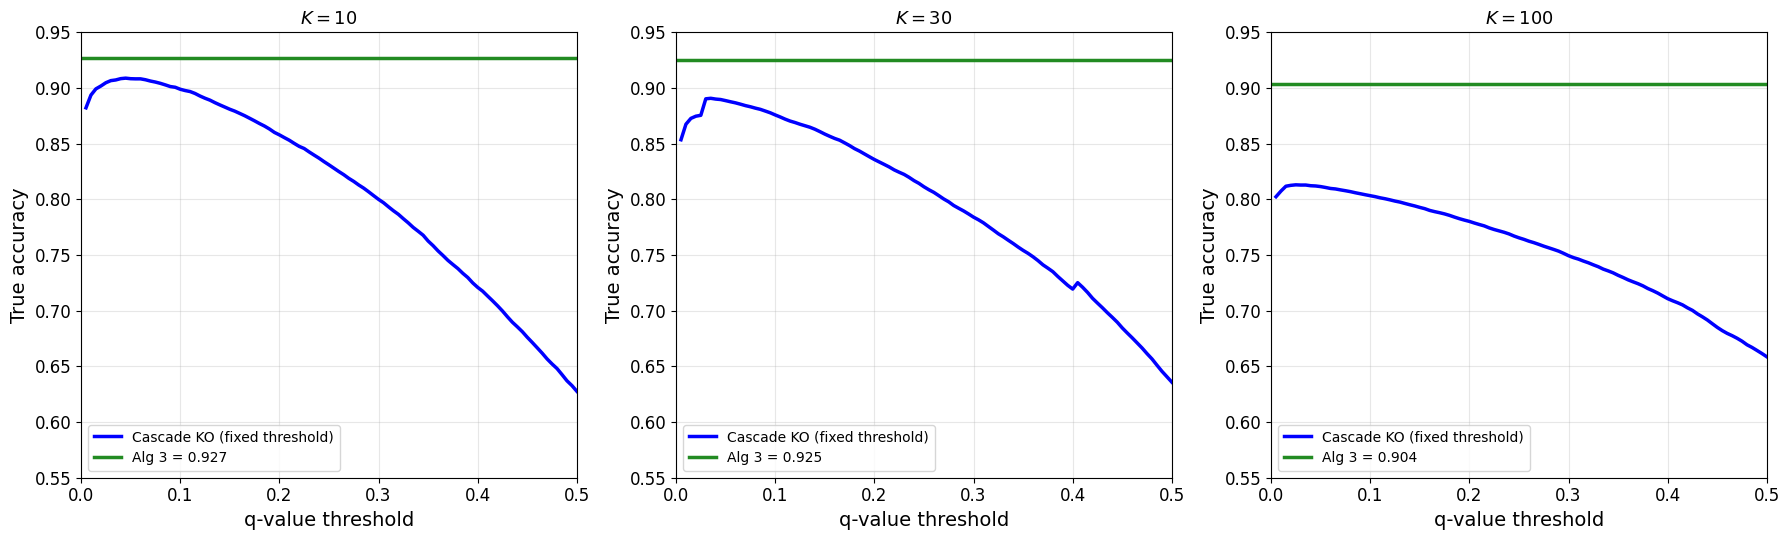

In [9]:
# ### Per-stage optimization with heterogeneous signal
def generate_hetero_signal_data(rng, N, K, null_frac=0.5):
    """Same as generate_signal_data_v2 but mu varies per class."""
    n_null = int(N * null_frac)
    n_signal = N - n_null
    mus = np.linspace(5.0, 1.0, K)
    weights = 1.0 / np.arange(1, K + 1) ** 1.3 + 0.02
    weights /= weights.sum()
    counts = np.round(weights * n_signal).astype(int)
    counts[0] += n_signal - counts.sum()
    Y = np.zeros(N, dtype=int)
    pos = n_null
    for k in range(K):
        if counts[k] > 0:
            Y[pos:pos + counts[k]] = k + 1
            pos += counts[k]
    rng.shuffle(Y)
    logits = rng.standard_normal((N, K))
    for i in range(N):
        if Y[i] > 0:
            logits[i, Y[i] - 1] += mus[Y[i] - 1]
    decoys = rng.standard_normal((N, K))
    return logits, decoys, Y, n_signal


def cascade_alg3_ko(logits, decoys, Y):
    """Alg 3: reuses ko_qvalues_perclass and ko_pi0."""
    N, K = logits.shape
    pi0_all = np.array([ko_pi0(logits[:, k], decoys[:, k])
                        for k in range(K)])
    keep = pi0_all < 0.999
    order = np.where(keep)[0]
    order = order[np.argsort(pi0_all[order])]
    remaining = np.ones(N, dtype=bool)
    q_out = np.full(N, np.inf)
    ic_out = np.zeros(N, dtype=bool)
    stage_info = []

    for k in order:
        idx = np.where(remaining)[0]
        if len(idx) == 0:
            break
        n_rem = len(idx)
        q = ko_qvalues_perclass(logits[idx, k], decoys[idx, k])
        pi0_k = ko_pi0(logits[idx, k], decoys[idx, k])
        best_acc = 0;
        best_q = None
        for q_th in np.linspace(0.005, 0.5, 200):
            D = np.sum(np.isfinite(q) & (q < q_th))
            if D == 0:
                continue
            TP_est = D * (1 - q_th)
            TN_est = n_rem * pi0_k - D * q_th
            acc = (TP_est + max(TN_est, 0)) / n_rem
            if acc > best_acc:
                best_acc = acc;
                best_q = q_th
        if best_q is None:
            continue
        disc = np.isfinite(q) & (q < best_q)
        if disc.sum() < max(1.0 / best_q, 2):
            continue
        disc_idx = idx[disc]
        q_out[disc_idx] = q[disc]
        ic_out[disc_idx] = (Y[disc_idx] == k + 1)
        remaining[disc_idx] = False
        stage_info.append({'class': k + 1, 'q_star': best_q,
                           'disc': int(disc.sum()),
                           'tp': int((Y[disc_idx] == k + 1).sum())})
    return q_out, ic_out, stage_info


def true_accuracy_at_q(q_values, ic_discovered,
                       is_argmax_correct, N, q_th):
    disc = np.isfinite(q_values) & (q_values < q_th)
    TP = (disc & ic_discovered).sum()
    TN = (~disc & ~is_argmax_correct).sum()
    return (TP + TN) / N

TH_HET = np.linspace(0.005, 0.50, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for panel, K in enumerate([10, 30, 100]):
    ax = axes[panel]
    rng_h = np.random.default_rng(42)
    lg, dc, Ya, ns = generate_hetero_signal_data(rng_h, 100_000, K)
    argmax_h = np.argmax(lg, axis=1)
    is_ac = (Ya > 0) & (argmax_h == Ya - 1)

    casc_curve = []
    for q_th in TH_HET:
        q_ko, ic_ko = cascade_final(
            lg, dc, Ya, max(q_th, 0.01), 'ko')
        casc_curve.append(
            true_accuracy_at_q(q_ko, ic_ko, is_ac, 100_000, q_th))

    # Alg 3
    q_a3, ic_a3, stages = cascade_alg3_ko(lg, dc, Ya)
    alg3_acc = true_accuracy_at_q(q_a3, ic_a3, is_ac, 100_000, 1.0)

    ax.plot(TH_HET, casc_curve, 'b-', lw=2.5,
            label='Cascade KO (fixed threshold)')
    ax.axhline(alg3_acc, color='forestgreen', ls='-', lw=2.5,
               label=f'Alg 3 = {alg3_acc:.3f}')
    ax.set_xlabel('q-value threshold')
    ax.set_ylabel('True accuracy')
    ax.set_title(f'$K = {K}$', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0.55, 0.95)
    ax.legend(fontsize=10)

    print(f'K={K}: best fixed={max(casc_curve):.4f}, '
          f'Alg3={alg3_acc:.4f}, '
          f'gain=+{alg3_acc - max(casc_curve):.4f}')

plt.tight_layout()
plt.savefig('figures/beyond_fdr_alg3_hetero.pdf',
            bbox_inches='tight', dpi=300)
plt.show()

## CIFAR-10 with external null calibration

**Data** (all from the same ~90%-accuracy model):
- `cifar10_test_logits.npz` — 10K test samples with labels (the test set $T$)
- `null_viki_cifar_test_logits.npy` — 10K pure-null logits from OOD images (calibration null $V_0^k$)

- For KO: pair each test sample with a random null sample as its knockoff
- For BH: compute per-class p-values against null_viki[:,k]
- For MM: G_score = max_k null_viki[i,k]

50 repetitions with reshuffled null pairing (affects KO/KI/MM; BH p-values are fixed).

In [ ]:
def empirical_pvalues_real(logits, val_null_sorted, K):
    N = logits.shape[0]
    pvals = np.empty((N, K))
    for k in range(K):
        null_sorted = val_null_sorted[k]
        M = len(null_sorted)
        ranks = np.searchsorted(null_sorted, logits[:, k], side='left')
        pvals[:, k] = (M - ranks + 1) / (M + 1)
    return pvals

In [11]:
test_data = np.load('cifar10_test_logits.npz')
logits, labels = test_data['logits'], test_data['labels']
null_all = np.load('null_viki_cifar_test_logits.npy')

N, K = logits.shape
Y = labels + 1  # cascade expects 1-indexed
is_correct = (logits.argmax(1) == labels)
F_score = logits.max(axis=1)

# p-values for cascade BH (fixed across reps)
val_null_sorted = {k: np.sort(null_all[:, k]) for k in range(K)}
pvals = empirical_pvalues_real(logits, val_null_sorted, K)

alphas = [0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
n_rep = 50
rng = np.random.default_rng(42)

results = {m: {a: [] for a in alphas} for m in
           ['SS GT','SS KO','SS KI','SS MM',
            'Cascade GT','Cascade KO','Cascade BH']}

for rep in range(n_rep):
    perm = rng.permutation(N)
    null_rep = null_all[perm]          # reshuffled null pairing
    G_score = null_rep.max(axis=1)
    F_KO = np.maximum(F_score, G_score)
    tw = F_score > G_score

    # single-stage q-values
    q_ss_gt = compute_gt_qvalues(F_score, is_correct)
    q_ss_ko = compute_ko_qvalues(F_KO, tw)
    q_ss_ki = compute_ki_qvalues(F_KO, tw)
    q_ss_mm = compute_mm_qvalues(F_score, G_score)

    for alpha in alphas:
        # single-stage
        for name, q in [('SS GT', q_ss_gt), ('SS KO', q_ss_ko),
                        ('SS KI', q_ss_ki), ('SS MM', q_ss_mm)]:
            disc = q < alpha
            nd = disc.sum()
            if nd == 0:
                results[name][alpha].append((0.0, 0))
            else:
                fdr = 1.0 - is_correct[disc].mean()
                results[name][alpha].append((fdr, nd))

        # cascade GT
        q_cgt, ic_cgt = cascade_final_gt(logits, null_rep, Y, alpha)
        disc = q_cgt < alpha
        nd = disc.sum()
        fdr = 0.0 if nd == 0 else 1.0 - ic_cgt[disc].mean()
        results['Cascade GT'][alpha].append((fdr, nd))

        #  cascade KO
        q_cko, ic_cko = cascade_final(logits, null_rep, Y, alpha, 'ko')
        disc = q_cko < alpha
        nd = disc.sum()
        fdr = 0.0 if nd == 0 else 1.0 - ic_cko[disc].mean()
        results['Cascade KO'][alpha].append((fdr, nd))

        #  cascade BH
        q_cbh, ic_cbh = cascade_final(pvals, null_rep, Y, alpha, 'bh')
        disc = q_cbh < alpha
        nd = disc.sum()
        fdr = 0.0 if nd == 0 else 1.0 - ic_cbh[disc].mean()
        results['Cascade BH'][alpha].append((fdr, nd))

print(f'N={N}, K={K}, acc={is_correct.mean():.1%}, null_size={len(null_all)}')
print(f'{n_rep} reps, labels 0-indexed -> Y 1-indexed for cascade')
print()
hdr = 'Method           |' + '|'.join(f'{a}:FDR/Pw ' for a in alphas)
print(hdr)
for name in ['SS GT','SS KO','SS KI','SS MM',
             'Cascade GT','Cascade KO','Cascade BH']:
    parts = []
    for a in alphas:
        fdrs = [x[0] for x in results[name][a]]
        pws  = [x[1] for x in results[name][a]]
        mf = np.mean(fdrs)
        mp = int(np.mean(pws))
        flag = '*' if mf > a else ''
        parts.append(f'{mf:.3f}{flag}/{mp}')
    print(f'{name:17s}|' + '|'.join(parts))

N=10000, K=10, acc=90.1%, null_size=10000
50 reps, labels 0-indexed -> Y 1-indexed for cascade

Method           |0.005:FDR/Pw |0.01:FDR/Pw |0.02:FDR/Pw |0.05:FDR/Pw |0.1:FDR/Pw |0.15:FDR/Pw |0.2:FDR/Pw 
SS GT            |0.000/0|0.000/0|0.020/5977|0.050/8762|0.099/10000|0.099/10000|0.099/10000
SS KO            |0.000/0|0.000/0|0.000/0|0.000/0|0.022/6166|0.044/8028|0.062/8477
SS KI            |0.000/0|0.000/0|0.000/0|0.000/0|0.000/0|0.017/2301|0.041/7673
SS MM            |0.000/0|0.000/0|0.000/0|0.000/0|0.022/6512|0.042/8513|0.074/9466
Cascade GT       |0.000/0|0.009/108|0.019/215|0.049/8913|0.100/9857|0.140/10000|0.188/10000
Cascade KO       |0.000/0|0.000/0|0.000/8|0.003/251|0.010/1546|0.028/6627|0.043/7224
Cascade BH       |0.000/0|0.000/0|0.000/0|0.000/69|0.020/1709|0.027/2619|0.040/2979


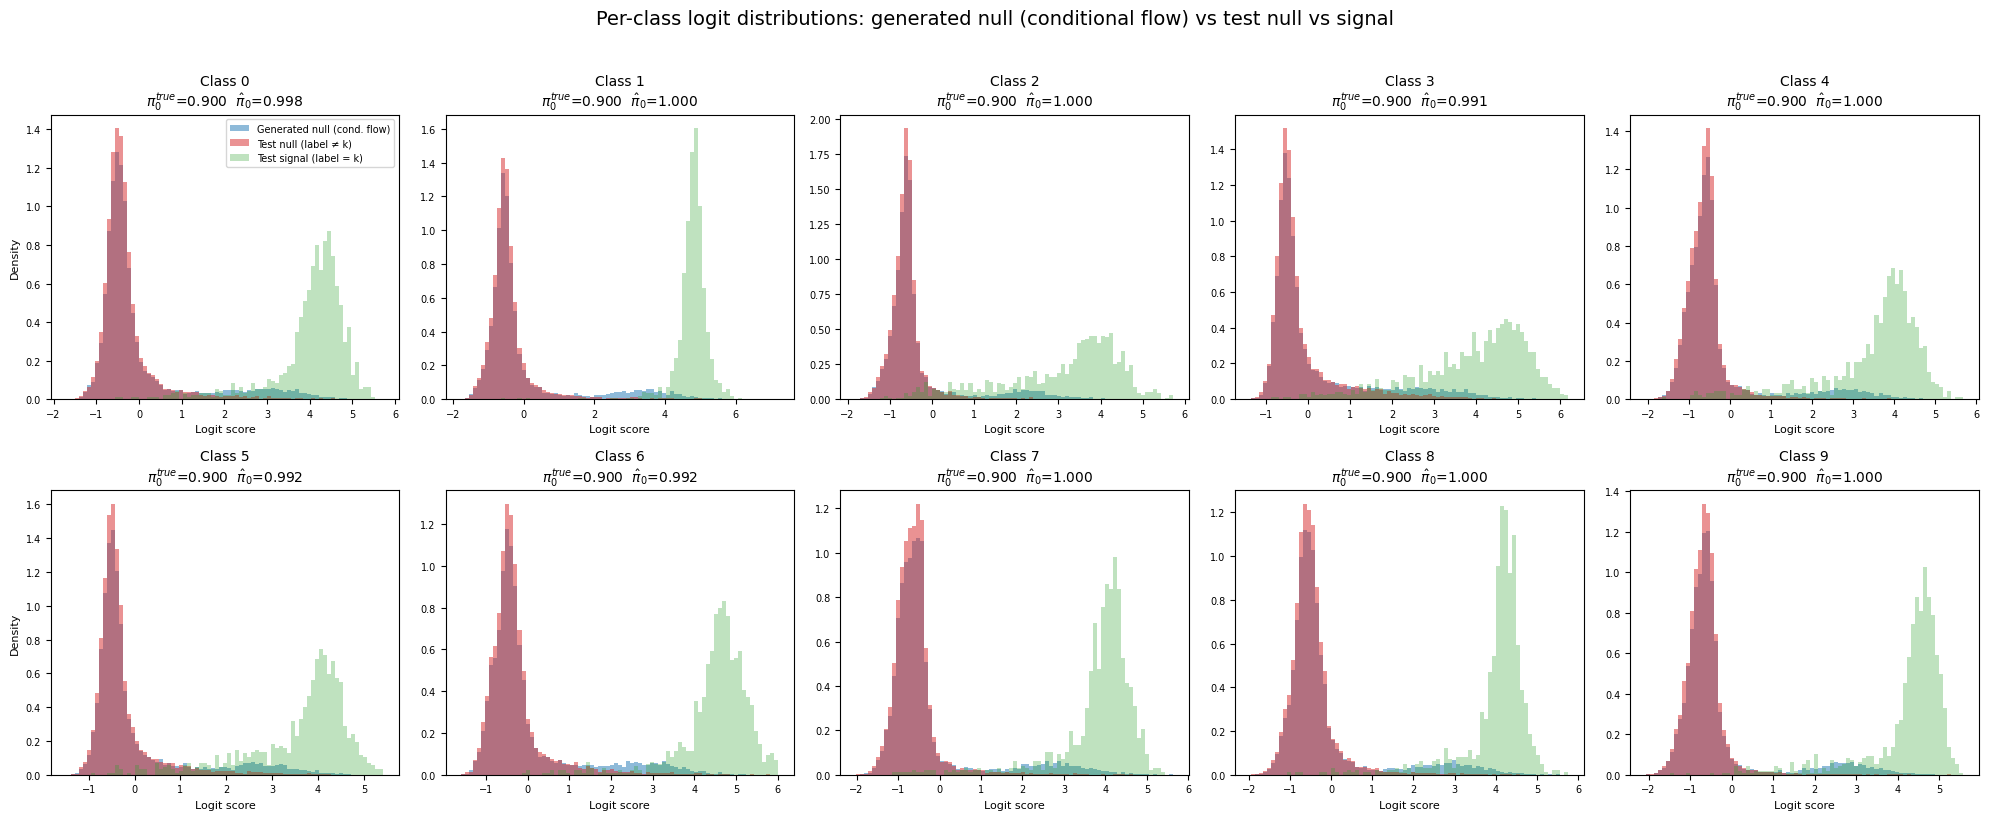

Class   true pi0    est pi0  n_signal  Gen null mean  Test null mean
    0      0.900      0.998      1000          0.011          -0.313
    1      0.900      1.000      1000         -0.019          -0.402
    2      0.900      1.000      1000         -0.326          -0.594
    3      0.900      0.991      1000          0.157          -0.149
    4      0.900      1.000      1000         -0.292          -0.612
    5      0.900      0.992      1000          0.011          -0.285
    6      0.900      0.992      1000          0.013          -0.297
    7      0.900      1.000      1000         -0.287          -0.617
    8      0.900      1.000      1000         -0.148          -0.484
    9      0.900      1.000      1000         -0.329          -0.670


In [14]:
test_data = np.load('/Users/vkfokina/Downloads/cifar10_test_logits.npz')
logits, labels = test_data['logits'], test_data['labels']
null_all = np.load('/Users/vkfokina/Downloads/null_viki_cifar_test_logits.npy')
N, K = logits.shape

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for k in range(K):
    ax = axes[k]
    test_null   = logits[labels != k, k]
    test_signal = logits[labels == k, k]
    cal_null    = null_all[:, k]

    true_pi0 = (labels != k).sum() / N
    cal_null_sorted = np.sort(cal_null)
    M = len(cal_null_sorted)
    ranks = np.searchsorted(cal_null_sorted, logits[:, k], side='left')
    pvals_k = (M - ranks + 1) / (M + 1)
    est_pi0 = storey_pi0(pvals_k)

    lo = min(test_null.min(), cal_null.min(), test_signal.min())
    hi = max(test_null.max(), cal_null.max(), test_signal.max())
    bins = np.linspace(lo, hi, 80)

    ax.hist(cal_null, bins=bins, density=True, alpha=0.5, label='Generated null (cond. flow)', color='tab:blue')
    ax.hist(test_null, bins=bins, density=True, alpha=0.5, label='Test null (label ≠ k)', color='tab:red')
    ax.hist(test_signal, bins=bins, density=True, alpha=0.3, label='Test signal (label = k)', color='tab:green')

    ax.set_title(f'Class {k}\n$\\pi_0^{{true}}$={true_pi0:.3f}  $\\hat{{\\pi}}_0$={est_pi0:.3f}', fontsize=10)
    ax.set_xlabel('Logit score', fontsize=8)
    if k % 5 == 0:
        ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if k == 0:
        ax.legend(fontsize=7)

plt.suptitle('Per-class logit distributions: generated null (conditional flow) vs test null vs signal', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('cifar10_nullviki_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"Class":>5}  {"true pi0":>9}  {"est pi0":>9}  {"n_signal":>8}  {"Gen null mean":>13}  {"Test null mean":>14}')
for k in range(K):
    true_pi0 = (labels != k).sum() / N
    cn = null_all[:, k]; tn = logits[labels != k, k]
    cal_s = np.sort(cn); M = len(cal_s)
    r = np.searchsorted(cal_s, logits[:, k], side='left')
    p = (M - r + 1) / (M + 1)
    print(f'{k:>5}  {true_pi0:>9.3f}  {storey_pi0(p):>9.3f}  {(labels==k).sum():>8}  {cn.mean():>13.3f}  {tn.mean():>14.3f}')

### CIFAR-10 + generated null: estimated π₀

Test: N=10000, K=10, accuracy=90.1%, correct=9015
Generated null: 10000 samples
Labels: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
  rep 10/50
  rep 20/50
  rep 30/50
  rep 40/50
  rep 50/50


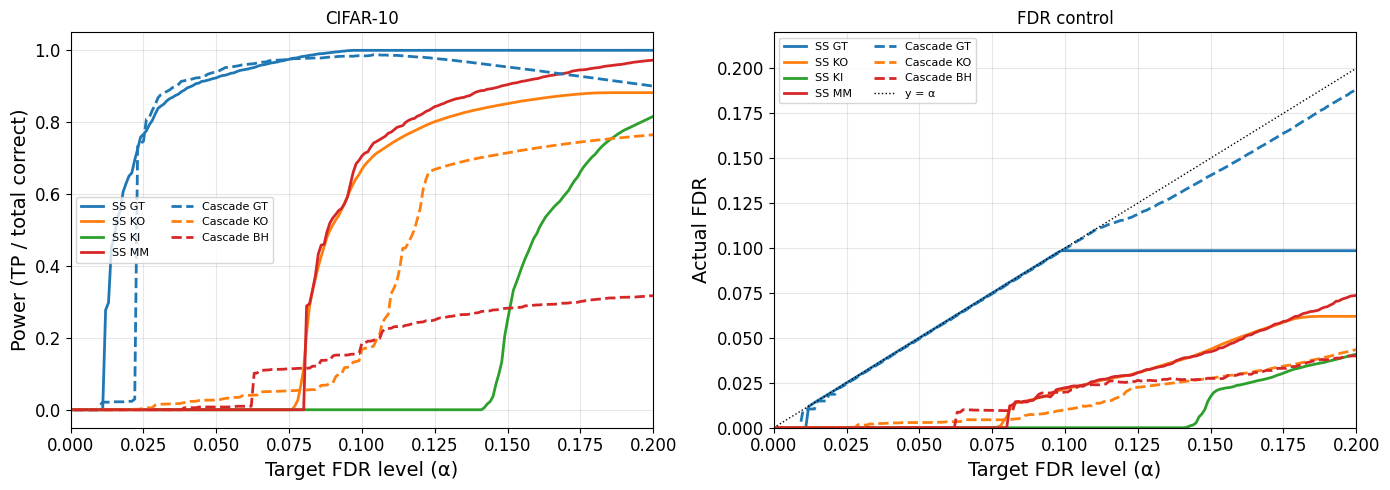


N=10000, K=10, accuracy=90.1%, correct=9015, reps=50

Actual FDR (should be ≤ α):
    Method α=0.005 α=0.01 α=0.02 α=0.05 α=0.1 α=0.15 α=0.2
     SS GT   0.000  0.000  0.020  0.050 0.099  0.099 0.099
     SS KO   0.000  0.000  0.000  0.000 0.022  0.044 0.062
     SS KI   0.000  0.000  0.000  0.000 0.000  0.017 0.041
     SS MM   0.000  0.000  0.000  0.000 0.022  0.042 0.074
Cascade GT   0.000  0.009  0.019  0.049 0.100  0.140 0.188
Cascade KO   0.000  0.000  0.000  0.003 0.010  0.028 0.043
Cascade BH   0.000  0.000  0.000  0.000 0.020  0.027 0.040

True positives (correct discoveries):
    Method  α=0.005  α=0.01  α=0.02  α=0.05  α=0.1  α=0.15  α=0.2
     SS GT        0       0    5858    8324   9015    9015   9015
     SS KO        0       0       0       0   6032    7677   7952
     SS KI        0       0       0       0      0    2254   7358
     SS MM        0       0       0       0   6367    8153   8769
Cascade GT        0     107     211    8472   8876    8596   8117
Cascade KO

In [17]:
test_data = np.load('/Users/vkfokina/Downloads/cifar10_test_logits.npz')
logits, labels = test_data['logits'], test_data['labels']
null_all = np.load('/Users/vkfokina/Downloads/null_viki_cifar_test_logits.npy')

N, K = logits.shape
Y = labels + 1  # cascade expects 1 indexed labels
is_correct = (logits.argmax(1) == labels)
F_score = logits.max(axis=1)
N_correct = is_correct.sum()

# p-values for cascade BH: rank each test logit_k against generated null
val_null_sorted = {k: np.sort(null_all[:, k]) for k in range(K)}
pvals = empirical_pvalues_real(logits, val_null_sorted, K)

print(f'Test: N={N}, K={K}, accuracy={is_correct.mean():.1%}, correct={N_correct}')
print(f'Generated null: {null_all.shape[0]} samples')
print(f'Labels: {np.bincount(labels)}')

alphas = np.arange(0.001, 0.201, 0.001)
n_rep = 50
rng = np.random.default_rng(42)

methods = ['SS GT', 'SS KO', 'SS KI', 'SS MM',
           'Cascade GT', 'Cascade KO', 'Cascade BH']
results = {m: {round(a, 3): [] for a in alphas} for m in methods}

for rep in range(n_rep):
    if (rep + 1) % 10 == 0:
        print(f'  rep {rep + 1}/{n_rep}')
    perm = rng.permutation(N)
    null_rep = null_all[perm]  # reshuffle pairing
    G_score = null_rep.max(axis=1)
    F_KO = np.maximum(F_score, G_score)
    tw = F_score > G_score

    q_ss_gt = compute_gt_qvalues(F_score, is_correct)
    q_ss_ko = compute_ko_qvalues(F_KO, tw)
    q_ss_ki = compute_ki_qvalues(F_KO, tw)
    q_ss_mm = compute_mm_qvalues(F_score, G_score)

    for alpha in alphas:
        a_key = round(alpha, 3)
        for name, q in [('SS GT', q_ss_gt), ('SS KO', q_ss_ko),
                        ('SS KI', q_ss_ki), ('SS MM', q_ss_mm)]:
            disc = q < alpha
            nd = disc.sum()
            tp = int((disc & is_correct).sum())
            if nd == 0:
                results[name][a_key].append((0.0, nd, 0))
            else:
                fdr = 1.0 - is_correct[disc].mean()
                results[name][a_key].append((fdr, nd, tp))

        q_cgt, ic_cgt = cascade_final_gt(logits, null_rep, Y, alpha)
        disc = q_cgt < alpha; nd = disc.sum()
        tp = int(ic_cgt[disc].sum()) if nd > 0 else 0
        fdr = 0.0 if nd == 0 else 1.0 - ic_cgt[disc].mean()
        results['Cascade GT'][a_key].append((fdr, nd, tp))

        q_cko, ic_cko = cascade_final(logits, null_rep, Y, alpha, 'ko')
        disc = q_cko < alpha; nd = disc.sum()
        tp = int(ic_cko[disc].sum()) if nd > 0 else 0
        fdr = 0.0 if nd == 0 else 1.0 - ic_cko[disc].mean()
        results['Cascade KO'][a_key].append((fdr, nd, tp))

        q_cbh, ic_cbh = cascade_final(pvals, null_rep, Y, alpha, 'bh')
        disc = q_cbh < alpha; nd = disc.sum()
        tp = int(ic_cbh[disc].sum()) if nd > 0 else 0
        fdr = 0.0 if nd == 0 else 1.0 - ic_cbh[disc].mean()
        results['Cascade BH'][a_key].append((fdr, nd, tp))

alpha_arr = np.array([round(a, 3) for a in alphas])
mean_fdr = {m: np.array([np.mean([x[0] for x in results[m][a]]) for a in alpha_arr]) for m in methods}
mean_pw  = {m: np.array([np.mean([x[2] for x in results[m][a]]) for a in alpha_arr]) for m in methods}

styles_ss = {'SS GT': ('C0', '-'), 'SS KO': ('C1', '-'), 'SS KI': ('C2', '-'), 'SS MM': ('C3', '-')}
styles_ca = {'Cascade GT': ('C0', '--'), 'Cascade KO': ('C1', '--'), 'Cascade BH': ('C3', '--')}
all_styles = {**styles_ss, **styles_ca}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for m, (c, ls) in all_styles.items():
    ax.plot(alpha_arr, mean_pw[m] / N_correct, color=c, ls=ls, lw=2, label=m)
ax.set_xlabel('Target FDR level (α)'); ax.set_ylabel('Power (TP / total correct)')
ax.set_title(f'CIFAR-10')
ax.legend(fontsize=8, ncol=2); ax.set_xlim(0, 0.20); ax.grid(True, alpha=0.3)

ax = axes[1]
for m, (c, ls) in all_styles.items():
    ax.plot(alpha_arr, mean_fdr[m], color=c, ls=ls, lw=2, label=m)
ax.plot(alpha_arr, alpha_arr, 'k:', lw=1, label='y = α')
ax.set_xlabel('Target FDR level (α)'); ax.set_ylabel('Actual FDR')
ax.set_title('FDR control')
ax.legend(fontsize=8, ncol=2); ax.set_xlim(0, 0.20); ax.set_ylim(0, 0.22); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cifar10_generated_null_power_fdr.png', dpi=150)
plt.show()

import pandas as pd

table_alphas = [0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
rows = []
for name in methods:
    row = {'Method': name}
    for a in table_alphas:
        mf = np.mean([x[0] for x in results[name][a]])
        mp = int(np.mean([x[2] for x in results[name][a]]))
        row[f'FDR (α={a})'] = mf
        row[f'TP (α={a})'] = mp
    rows.append(row)

df_fdr = pd.DataFrame([{
    'Method': r['Method'],
    **{f'α={a}': f"{r[f'FDR (α={a})']:.3f}" for a in table_alphas}
} for r in rows])

df_pw = pd.DataFrame([{
    'Method': r['Method'],
    **{f'α={a}': r[f'TP (α={a})'] for a in table_alphas}
} for r in rows])

print(f'\nN={N}, K={K}, accuracy={is_correct.mean():.1%}, correct={N_correct}, reps={n_rep}\n')
print('Actual FDR (should be ≤ α):')
print(df_fdr.to_string(index=False))
print(f'\nTrue positives (correct discoveries):')
print(df_pw.to_string(index=False))

df_power = pd.DataFrame([{
    'Method': r['Method'],
    **{f'α={a}': f"{r[f'TP (α={a})'] / N_correct:.3f}" for a in table_alphas}
} for r in rows])
print(f'\nPower (TP / N_correct, N_correct={N_correct}):')
print(df_power.to_string(index=False))

### CIFAR-10 + generated null: fixed class order + true π₀

Same setup as above but with two changes:
1. **True π₀** used everywhere (SS MM: π₀ = 1 − accuracy; cascade BH: π₀ = 0.90 per class)
2. **Fixed class order** by per-class accuracy (strongest first) — replaces π₀-based ordering in cascade

In [21]:
def empirical_pvalues_real(logits, val_null_sorted, K):
    N = logits.shape[0]
    pvals = np.empty((N, K))
    for k in range(K):
        null_sorted = val_null_sorted[k]
        M = len(null_sorted)
        ranks = np.searchsorted(null_sorted, logits[:, k], side='left')
        pvals[:, k] = (M - ranks + 1) / (M + 1)
    return pvals

Per-class accuracy: {0: np.float64(0.942), 1: np.float64(0.993), 2: np.float64(0.751), 3: np.float64(0.866), 4: np.float64(0.868), 5: np.float64(0.835), 6: np.float64(0.968), 7: np.float64(0.94), 8: np.float64(0.946), 9: np.float64(0.906)}
Fixed order (strongest first): [1, 6, 8, 0, 7, 9, 4, 3, 5, 2]
True pi0 SS: 0.0985, per-class: 0.90
  rep 10/50
  rep 20/50
  rep 30/50
  rep 40/50
  rep 50/50


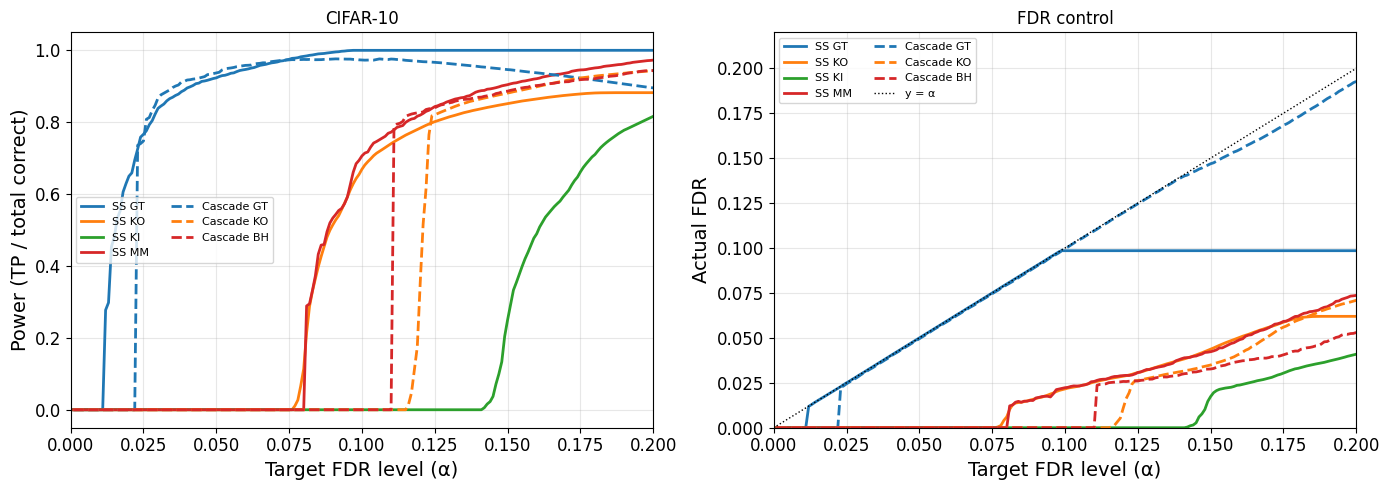


Fixed order + true π₀
N=10000, K=10, acc=90.1%, true_u03c0₀_ss=0.0985, per-class=0.90
Order: [1, 6, 8, 0, 7, 9, 4, 3, 5, 2], reps=50

Actual FDR (should be ≤ α):
    Method α=0.005 α=0.01 α=0.02 α=0.05 α=0.1 α=0.15 α=0.2
     SS GT   0.000  0.000  0.020  0.050 0.099  0.099 0.099
     SS KO   0.000  0.000  0.000  0.000 0.022  0.044 0.062
     SS KI   0.000  0.000  0.000  0.000 0.000  0.017 0.041
     SS MM   0.000  0.000  0.000  0.000 0.022  0.042 0.074
Cascade GT   0.000  0.000  0.000  0.050 0.100  0.147 0.193
Cascade KO   0.000  0.000  0.000  0.000 0.000  0.035 0.071
Cascade BH   0.000  0.000  0.000  0.000 0.000  0.033 0.053

True positives (correct discoveries):
    Method  α=0.005  α=0.01  α=0.02  α=0.05  α=0.1  α=0.15  α=0.2
     SS GT        0       0    5858    8324   9015    9015   9015
     SS KO        0       0       0       0   6032    7677   7952
     SS KI        0       0       0       0      0    2254   7358
     SS MM        0       0       0       0   6367    8153   8

In [22]:
test_data = np.load('/Users/vkfokina/Downloads/cifar10_test_logits.npz')
logits, labels = test_data['logits'], test_data['labels']
null_all = np.load('/Users/vkfokina/Downloads/null_viki_cifar_test_logits.npy')

N, K = logits.shape
Y = labels + 1
is_correct = (logits.argmax(1) == labels)
F_score = logits.max(axis=1)
N_correct = is_correct.sum()

# Fixed order: per-class accuracy, strongest first
acc_per_class = np.array([is_correct[labels == k].mean() for k in range(K)])
order = np.argsort(-acc_per_class)
print(f'Per-class accuracy: {dict(zip(range(K), acc_per_class.round(3)))}')
print(f'Fixed order (strongest first): {order.tolist()}')

# True pi0
true_pi0_ss = 1.0 - is_correct.mean()
true_pi0_perclass = np.full(K, 1.0 - 1.0 / K)  # 0.90 for balanced K=10
print(f'True pi0 SS: {true_pi0_ss:.4f}, per-class: {true_pi0_perclass[0]:.2f}')

# p-values for cascade BH
val_null_sorted = {k: np.sort(null_all[:, k]) for k in range(K)}
pvals = empirical_pvalues_real(logits, val_null_sorted, K)

def bh_qvalues_pi0(pvals, pi0):
    n = len(pvals)
    idx = np.argsort(pvals)
    fdp = n * pi0 * pvals[idx] / np.arange(1, n + 1)
    q_sorted = np.minimum(np.minimum.accumulate(fdp[::-1])[::-1], 1.0)
    q = np.empty(n)
    q[idx] = q_sorted
    return q

def compute_mm_qvalues_pi0(F_score, G_score, pi0):
    N = len(F_score)
    Z_asc = np.sort(G_score)
    W_asc = np.sort(F_score)
    rank_w = np.searchsorted(W_asc, Z_asc, side='right').astype(float)
    rank_z = np.arange(1, N + 1, dtype=float)
    h = np.clip(rank_w / ((1 - pi0) * rank_z) - pi0 / (1 - pi0), 0, 1)
    h_rcum = np.zeros(N + 1)
    h_rcum[:N] = np.cumsum(h[::-1])[::-1]
    desc = np.argsort(-F_score)
    z_start = np.searchsorted(Z_asc, F_score[desc], side='right')
    fp = pi0 * (N - z_start) + (1 - pi0) * h_rcum[z_start]
    fdp = fp / np.arange(1, N + 1, dtype=float)
    q_sorted = np.minimum.accumulate(fdp[::-1])[::-1]
    q = np.empty(N)
    q[desc] = q_sorted
    return q

def cascade_fixord_gt(data, decoys, Y, alpha, order):
    N, K = data.shape
    remaining = np.ones(N, dtype=bool)
    q_out = np.full(N, np.inf)
    ic_out = np.zeros(N, dtype=bool)
    min_rej = 1.0 / alpha
    for k in order:
        idx = np.where(remaining)[0]
        if len(idx) == 0: break
        is_tp = (Y[idx] == k + 1)
        q = gt_qvalues(data[idx, k], is_tp)
        disc = q < alpha
        if int(disc.sum()) < min_rej: break
        di = idx[disc]
        q_out[di] = q[disc]
        ic_out[di] = is_tp[disc]
        remaining[di] = False
    return q_out, ic_out

def cascade_fixord_ko(data, decoys, Y, alpha, order):
    N, K = data.shape
    remaining = np.ones(N, dtype=bool)
    q_out = np.full(N, np.inf)
    ic_out = np.zeros(N, dtype=bool)
    min_rej = 1.0 / alpha
    for k in order:
        idx = np.where(remaining)[0]
        if len(idx) == 0: break
        q = ko_qvalues_perclass(data[idx, k], decoys[idx, k])
        disc = q < alpha
        if int(disc.sum()) < min_rej: break
        di = idx[disc]
        q_out[di] = q[disc]
        ic_out[di] = (Y[di] == k + 1)
        remaining[di] = False
    return q_out, ic_out

def cascade_fixord_bh(pvals_data, Y, alpha, order, true_pi0):
    N, K = pvals_data.shape
    remaining = np.ones(N, dtype=bool)
    q_out = np.full(N, np.inf)
    ic_out = np.zeros(N, dtype=bool)
    min_rej = 1.0 / alpha
    for k in order:
        idx = np.where(remaining)[0]
        if len(idx) == 0: break
        q = bh_qvalues_pi0(pvals_data[idx, k], true_pi0[k])
        disc = q < alpha
        if int(disc.sum()) < min_rej: break
        di = idx[disc]
        q_out[di] = q[disc]
        ic_out[di] = (Y[di] == k + 1)
        remaining[di] = False
    return q_out, ic_out

alphas = np.arange(0.001, 0.201, 0.001)
n_rep = 50
rng = np.random.default_rng(42)

methods = ['SS GT', 'SS KO', 'SS KI', 'SS MM',
           'Cascade GT', 'Cascade KO', 'Cascade BH']
results_fo = {m: {round(a, 3): [] for a in alphas} for m in methods}

for rep in range(n_rep):
    if (rep + 1) % 10 == 0:
        print(f'  rep {rep + 1}/{n_rep}')
    perm = rng.permutation(N)
    null_rep = null_all[perm]
    G_score = null_rep.max(axis=1)
    F_KO = np.maximum(F_score, G_score)
    tw = F_score > G_score

    q_ss_gt = compute_gt_qvalues(F_score, is_correct)
    q_ss_ko = compute_ko_qvalues(F_KO, tw)
    q_ss_ki = compute_ki_qvalues(F_KO, tw)
    q_ss_mm = compute_mm_qvalues_pi0(F_score, G_score, true_pi0_ss)

    for alpha in alphas:
        a_key = round(alpha, 3)
        for name, q in [('SS GT', q_ss_gt), ('SS KO', q_ss_ko),
                        ('SS KI', q_ss_ki), ('SS MM', q_ss_mm)]:
            disc = q < alpha
            nd = disc.sum()
            tp = int((disc & is_correct).sum())
            if nd == 0:
                results_fo[name][a_key].append((0.0, 0, 0))
            else:
                fdr = 1.0 - is_correct[disc].mean()
                results_fo[name][a_key].append((fdr, nd, tp))

        q_cgt, ic_cgt = cascade_fixord_gt(logits, null_rep, Y, alpha, order)
        disc = q_cgt < alpha; nd = disc.sum()
        tp = int(ic_cgt[disc].sum()) if nd > 0 else 0
        fdr = 0.0 if nd == 0 else 1.0 - ic_cgt[disc].mean()
        results_fo['Cascade GT'][a_key].append((fdr, nd, tp))

        q_cko, ic_cko = cascade_fixord_ko(logits, null_rep, Y, alpha, order)
        disc = q_cko < alpha; nd = disc.sum()
        tp = int(ic_cko[disc].sum()) if nd > 0 else 0
        fdr = 0.0 if nd == 0 else 1.0 - ic_cko[disc].mean()
        results_fo['Cascade KO'][a_key].append((fdr, nd, tp))

        q_cbh, ic_cbh = cascade_fixord_bh(pvals, Y, alpha, order, true_pi0_perclass)
        disc = q_cbh < alpha; nd = disc.sum()
        tp = int(ic_cbh[disc].sum()) if nd > 0 else 0
        fdr = 0.0 if nd == 0 else 1.0 - ic_cbh[disc].mean()
        results_fo['Cascade BH'][a_key].append((fdr, nd, tp))

alpha_arr = np.array([round(a, 3) for a in alphas])
mean_fdr_fo = {m: np.array([np.mean([x[0] for x in results_fo[m][a]]) for a in alpha_arr]) for m in methods}
mean_pw_fo  = {m: np.array([np.mean([x[2] for x in results_fo[m][a]]) for a in alpha_arr]) for m in methods}

styles_ss = {'SS GT': ('C0', '-'), 'SS KO': ('C1', '-'), 'SS KI': ('C2', '-'), 'SS MM': ('C3', '-')}
styles_ca = {'Cascade GT': ('C0', '--'), 'Cascade KO': ('C1', '--'), 'Cascade BH': ('C3', '--')}
all_styles = {**styles_ss, **styles_ca}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for m, (c, ls) in all_styles.items():
    ax.plot(alpha_arr, mean_pw_fo[m] / N_correct, color=c, ls=ls, lw=2, label=m)
ax.set_xlabel('Target FDR level (α)'); ax.set_ylabel('Power (TP / total correct)')
ax.set_title(f'CIFAR-10')
ax.legend(fontsize=8, ncol=2); ax.set_xlim(0, 0.20); ax.grid(True, alpha=0.3)

ax = axes[1]
for m, (c, ls) in all_styles.items():
    ax.plot(alpha_arr, mean_fdr_fo[m], color=c, ls=ls, lw=2, label=m)
ax.plot(alpha_arr, alpha_arr, 'k:', lw=1, label='y = α')
ax.set_xlabel('Target FDR level (α)'); ax.set_ylabel('Actual FDR')
ax.set_title('FDR control')
ax.legend(fontsize=8, ncol=2); ax.set_xlim(0, 0.20); ax.set_ylim(0, 0.22); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cifar10_balanced_truepi0_power_fdr.png', dpi=150)
plt.show()


import pandas as pd
table_alphas = [0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
rows = []
for name in methods:
    row = {'Method': name}
    for a in table_alphas:
        mf = np.mean([x[0] for x in results_fo[name][a]])
        mp = int(np.mean([x[2] for x in results_fo[name][a]]))
        row[f'FDR (α={a})'] = mf
        row[f'TP (α={a})'] = mp
    rows.append(row)

df_fdr = pd.DataFrame([{
    'Method': r['Method'],
    **{f'α={a}': f"{r[f'FDR (α={a})']:.3f}" for a in table_alphas}
} for r in rows])

df_pw = pd.DataFrame([{
    'Method': r['Method'],
    **{f'α={a}': r[f'TP (α={a})'] for a in table_alphas}
} for r in rows])

print(f'\nFixed order + true π₀')
print(f'N={N}, K={K}, acc={is_correct.mean():.1%}, true_u03c0₀_ss={true_pi0_ss:.4f}, per-class={true_pi0_perclass[0]:.2f}')
print(f'Order: {order.tolist()}, reps={n_rep}\n')
print('Actual FDR (should be ≤ α):')
print(df_fdr.to_string(index=False))
print(f'\nTrue positives (correct discoveries):')
print(df_pw.to_string(index=False))

## CIFAR-10 with imbalanced classes (power-law subsampling)

Subsample the test set so class sizes follow a power-law $n_k \propto 1/(k{+}1)^{1.3}$,
matching the simulation setup. Class 0 keeps all 1000 samples; class 9 keeps ~80.
This creates per-class $\pi_0$ heterogeneity that the cascade can exploit.

Imbalanced test: N=2438, K=10, accuracy=91.1%
Samples per class: [1000, 418, 255, 181, 141, 115, 98, 85, 76, 69]
Correctly classified: 2221
  Class 0: n=1000, π₀=0.590, acc=94.2%
  Class 1: n= 418, π₀=0.829, acc=99.3%
  Class 2: n= 255, π₀=0.895, acc=72.2%
  Class 3: n= 181, π₀=0.926, acc=85.6%
  Class 4: n= 141, π₀=0.942, acc=88.7%
  Class 5: n= 115, π₀=0.953, acc=82.6%
  Class 6: n=  98, π₀=0.960, acc=93.9%
  Class 7: n=  85, π₀=0.965, acc=97.6%
  Class 8: n=  76, π₀=0.969, acc=94.7%
  Class 9: n=  69, π₀=0.972, acc=84.1%
  rep 10/50
  rep 20/50
  rep 30/50
  rep 40/50
  rep 50/50


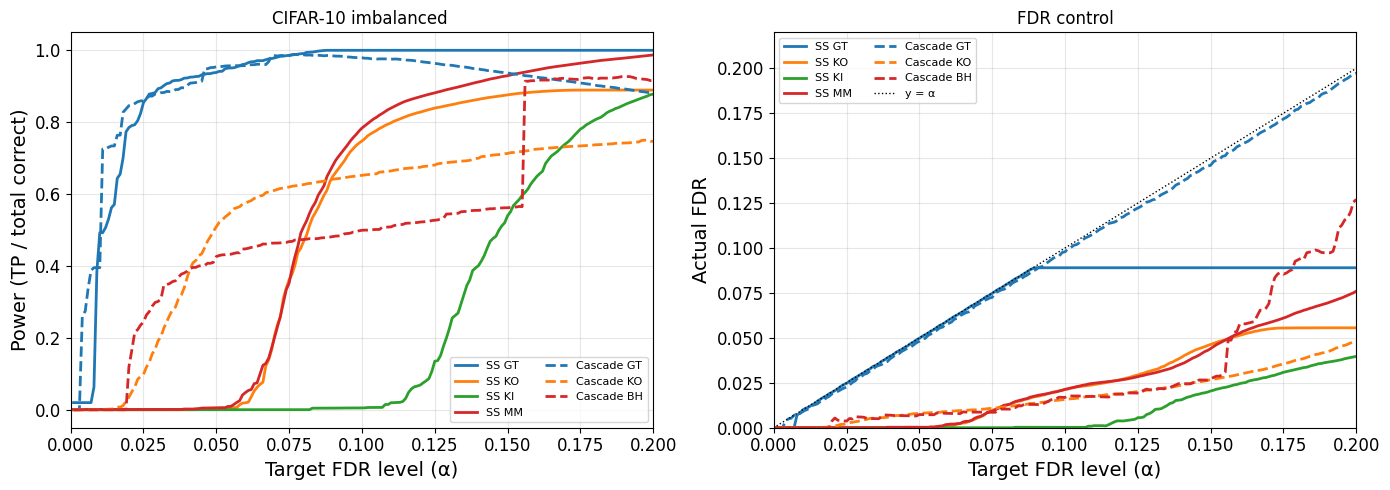


N=2438, K=10, acc=91.1%, correct=2221, reps=50
Class sizes: [1000, 418, 255, 181, 141, 115, 98, 85, 76, 69]

Actual FDR (should be ≤ α):
    Method α=0.005 α=0.01 α=0.02 α=0.05 α=0.1 α=0.15 α=0.2
     SS GT   0.000  0.010  0.020  0.050 0.089  0.089 0.089
     SS KO   0.000  0.000  0.000  0.000 0.021  0.046 0.056
     SS KI   0.000  0.000  0.000  0.000 0.000  0.020 0.040
     SS MM   0.000  0.000  0.000  0.000 0.021  0.044 0.076
Cascade GT   0.005  0.009  0.019  0.048 0.098  0.146 0.197
Cascade KO   0.000  0.000  0.001  0.008 0.016  0.027 0.048
Cascade BH   0.000  0.000  0.004  0.007 0.017  0.027 0.127

True positives (correct discoveries):
    Method  α=0.005  α=0.01  α=0.02  α=0.05  α=0.1  α=0.15  α=0.2
     SS GT       44    1094    1744    2084   2221    2221   2221
     SS KO        0       0       0      10   1660    1945   1975
     SS KI        0       0       0       0     11    1198   1950
     SS MM        1       1       1      11   1740    2064   2192
Cascade GT      609  

In [16]:
test_data = np.load('/Users/vkfokina/Downloads/cifar10_test_logits.npz')
logits_full, labels_full = test_data['logits'], test_data['labels']
null_all = np.load('/Users/vkfokina/Downloads/null_viki_cifar_test_logits.npy')
K = logits_full.shape[1]

# Power-law class sizes: n_k ∝ 1/(k+1)^1.3 (class 0 → 1000, class 9 → ~80)
rng_sub = np.random.default_rng(123)
raw = np.array([1.0 / (k + 1)**1.3 + 0.02 for k in range(K)])
n_per_class = np.clip(np.round(raw / raw.max() * 1000).astype(int), 50, 1000)

keep = []
for k in range(K):
    ck = np.where(labels_full == k)[0]
    n = min(n_per_class[k], len(ck))
    keep.append(rng_sub.choice(ck, size=n, replace=False))
    n_per_class[k] = n
keep = np.sort(np.concatenate(keep))

logits_imb = logits_full[keep]
labels_imb = labels_full[keep]
N = len(keep)
Y = labels_imb + 1
is_correct = (logits_imb.argmax(1) == labels_imb)
F_score = logits_imb.max(1)
N_correct = is_correct.sum()

print(f'Imbalanced test: N={N}, K={K}, accuracy={is_correct.mean():.1%}')
print(f'Samples per class: {n_per_class.tolist()}')
print(f'Correctly classified: {N_correct}')
for k in range(K):
    nk = n_per_class[k]
    pi0k = 1 - nk / N
    acc_k = is_correct[labels_imb == k].mean() if nk > 0 else 0
    print(f'  Class {k}: n={nk:4d}, π₀={pi0k:.3f}, acc={acc_k:.1%}')

# p-values for cascade BH (full null_all for resolution)
val_null_sorted = {k: np.sort(null_all[:, k]) for k in range(K)}
pvals = empirical_pvalues_real(logits_imb, val_null_sorted, K)

alphas = np.arange(0.001, 0.201, 0.001)
n_rep = 50
rng = np.random.default_rng(42)

methods = ['SS GT', 'SS KO', 'SS KI', 'SS MM',
           'Cascade GT', 'Cascade KO', 'Cascade BH']
results_imb = {m: {round(a, 3): [] for a in alphas} for m in methods}

N_null_avail = null_all.shape[0]

for rep in range(n_rep):
    if (rep + 1) % 10 == 0:
        print(f'  rep {rep + 1}/{n_rep}')
    perm = rng.permutation(N_null_avail)[:N]
    null_rep = null_all[perm]
    G_score = null_rep.max(axis=1)
    F_KO = np.maximum(F_score, G_score)
    tw = F_score > G_score

    q_ss_gt = compute_gt_qvalues(F_score, is_correct)
    q_ss_ko = compute_ko_qvalues(F_KO, tw)
    q_ss_ki = compute_ki_qvalues(F_KO, tw)
    q_ss_mm = compute_mm_qvalues(F_score, G_score)

    for alpha in alphas:
        a_key = round(alpha, 3)
        for name, q in [('SS GT', q_ss_gt), ('SS KO', q_ss_ko),
                        ('SS KI', q_ss_ki), ('SS MM', q_ss_mm)]:
            disc = q < alpha
            nd = disc.sum()
            tp = (disc & is_correct).sum()
            if nd == 0:
                results_imb[name][a_key].append((0.0, 0, 0))
            else:
                fdr = 1.0 - is_correct[disc].mean()
                results_imb[name][a_key].append((fdr, nd, int(tp)))

        q_cgt, ic_cgt = cascade_final_gt(logits_imb, null_rep, Y, alpha)
        disc = q_cgt < alpha; nd = disc.sum()
        tp = int(ic_cgt[disc].sum()) if nd > 0 else 0
        fdr = 0.0 if nd == 0 else 1.0 - ic_cgt[disc].mean()
        results_imb['Cascade GT'][a_key].append((fdr, nd, tp))

        q_cko, ic_cko = cascade_final(logits_imb, null_rep, Y, alpha, 'ko')
        disc = q_cko < alpha; nd = disc.sum()
        tp = int(ic_cko[disc].sum()) if nd > 0 else 0
        fdr = 0.0 if nd == 0 else 1.0 - ic_cko[disc].mean()
        results_imb['Cascade KO'][a_key].append((fdr, nd, tp))

        q_cbh, ic_cbh = cascade_final(pvals, null_rep, Y, alpha, 'bh')
        disc = q_cbh < alpha; nd = disc.sum()
        tp = int(ic_cbh[disc].sum()) if nd > 0 else 0
        fdr = 0.0 if nd == 0 else 1.0 - ic_cbh[disc].mean()
        results_imb['Cascade BH'][a_key].append((fdr, nd, tp))

alpha_arr = np.array([round(a, 3) for a in alphas])
mean_fdr = {m: np.array([np.mean([x[0] for x in results_imb[m][a]]) for a in alpha_arr]) for m in methods}
mean_pw  = {m: np.array([np.mean([x[2] for x in results_imb[m][a]]) for a in alpha_arr]) for m in methods}

styles_ss = {'SS GT': ('C0', '-'), 'SS KO': ('C1', '-'), 'SS KI': ('C2', '-'), 'SS MM': ('C3', '-')}
styles_ca = {'Cascade GT': ('C0', '--'), 'Cascade KO': ('C1', '--'), 'Cascade BH': ('C3', '--')}
all_styles = {**styles_ss, **styles_ca}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for m, (c, ls) in all_styles.items():
    ax.plot(alpha_arr, mean_pw[m] / N_correct, color=c, ls=ls, lw=2, label=m)
ax.set_xlabel('Target FDR level (α)'); ax.set_ylabel('Power (TP / total correct)')
ax.set_title(f'CIFAR-10 imbalanced ')
ax.legend(fontsize=8, ncol=2); ax.set_xlim(0, 0.20); ax.grid(True, alpha=0.3)

ax = axes[1]
for m, (c, ls) in all_styles.items():
    ax.plot(alpha_arr, mean_fdr[m], color=c, ls=ls, lw=2, label=m)
ax.plot(alpha_arr, alpha_arr, 'k:', lw=1, label='y = α')
ax.set_xlabel('Target FDR level (α)'); ax.set_ylabel('Actual FDR')
ax.set_title('FDR control')
ax.legend(fontsize=8, ncol=2); ax.set_xlim(0, 0.20); ax.set_ylim(0, 0.22); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cifar10_imbalanced_power_fdr.png', dpi=150)
plt.show()


import pandas as pd
table_alphas = [0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
rows = []
for name in methods:
    row = {'Method': name}
    for a in table_alphas:
        mf = np.mean([x[0] for x in results_imb[name][a]])
        mp = int(np.mean([x[2] for x in results_imb[name][a]]))
        row[f'FDR (α={a})'] = mf
        row[f'TP (α={a})'] = mp
    rows.append(row)

df_fdr = pd.DataFrame([{
    'Method': r['Method'],
    **{f'α={a}': f"{r[f'FDR (α={a})']:.3f}" for a in table_alphas}
} for r in rows])

df_pw = pd.DataFrame([{
    'Method': r['Method'],
    **{f'α={a}': r[f'TP (α={a})'] for a in table_alphas}
} for r in rows])

print(f'\nN={N}, K={K}, acc={is_correct.mean():.1%}, correct={N_correct}, reps={n_rep}')
print(f'Class sizes: {n_per_class.tolist()}\n')
print('Actual FDR (should be ≤ α):')
print(df_fdr.to_string(index=False))
print(f'\nTrue positives (correct discoveries):')
print(df_pw.to_string(index=False))

df_power = pd.DataFrame([{
    'Method': r['Method'],
    **{f'α={a}': f"{r[f'TP (α={a})'] / N_correct:.3f}" for a in table_alphas}
} for r in rows])
print(f'\nPower (TP / N_correct, N_correct={N_correct}):')
print(df_power.to_string(index=False))

Heterogeneity effect check (power vs α for different β)

<>:114: SyntaxWarning: invalid escape sequence '\p'
<>:114: SyntaxWarning: invalid escape sequence '\p'
/var/folders/p9/sgb833ss329d3qxgnfqt76dr0000gn/T/ipykernel_10740/1048393042.py:114: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title(f'β = {beta}   ($\pi_0$ ∈ [{lo:.2f}, {hi:.2f}])',
β=0.0: 100%|██████████| 50/50 [01:32<00:00,  1.84s/it]
/Users/vkfokina/PycharmProjects/FDR/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
β=2.0: 100%|██████████| 50/50 [01:23<00:00,  1.67s/it]


β=0.0: π₀ range [0.950, 0.950], signal/class = [5000, 5000]
β=0.6: π₀ range [0.890, 0.971], signal/class = [2915, 10965]
β=1.3: π₀ range [0.795, 0.986], signal/class = [1410, 20517]
β=2.0: π₀ range [0.709, 0.991], signal/class = [857, 29147]


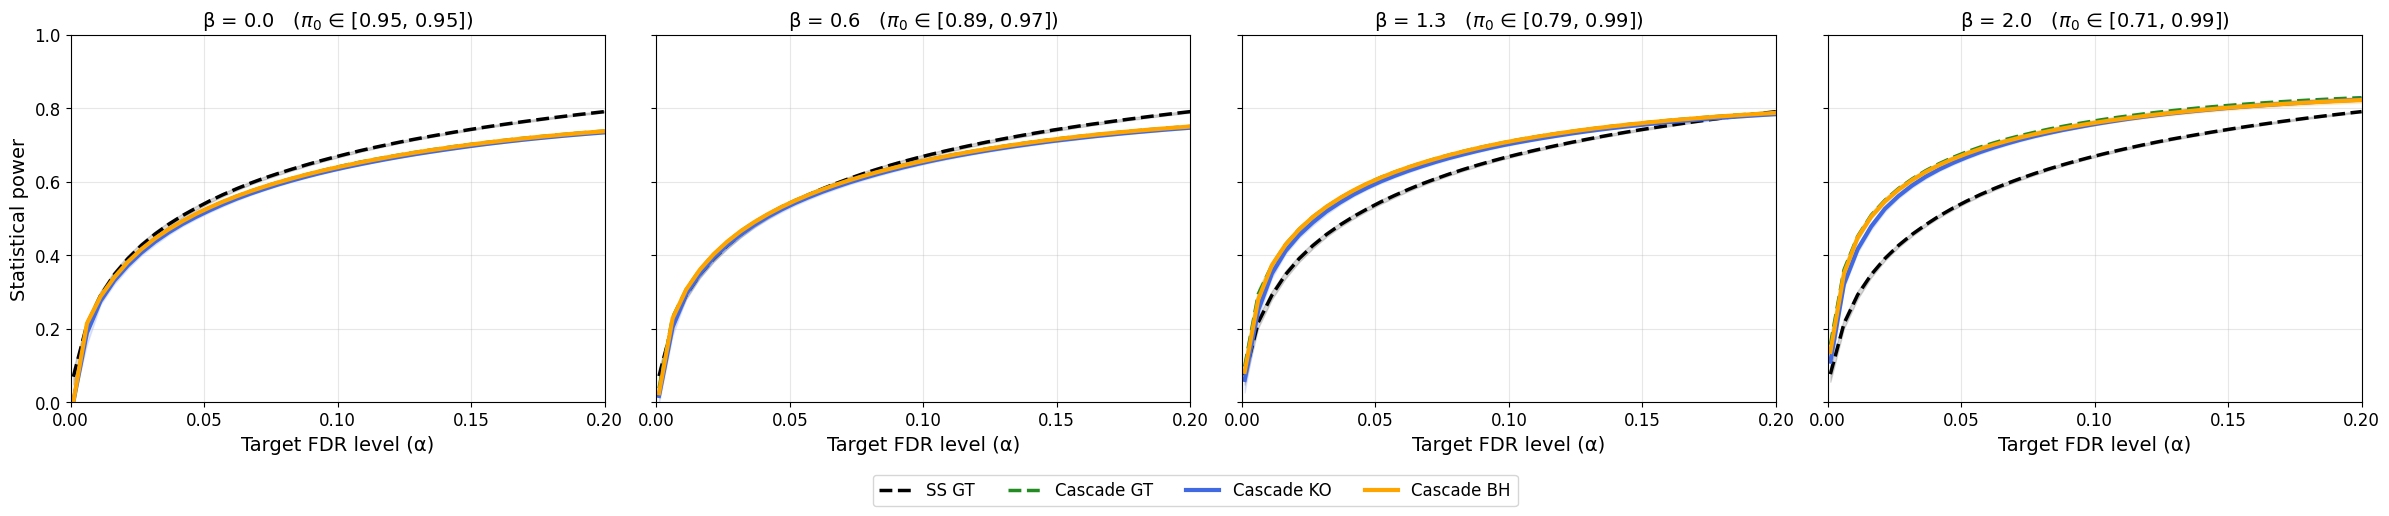

In [10]:
REPS_H = 50
BETAS_H = [0.0, 0.6, 1.3, 2.0]
ALPHA_GRID_H = np.linspace(0.001, 0.20, 40)
N_H = 100_000
NULL_FRAC_H = 0.5
MU_H = 3.0
K_H = 10
N_null_H = int(N_H * NULL_FRAC_H)
N_signal_H = N_H - N_null_H

def make_signal_counts_h(beta, K, n_signal):
    if beta == 0:
        weights = np.ones(K)
    else:
        weights = 1.0 / np.arange(1, K + 1) ** beta + 0.02
    weights /= weights.sum()
    counts = np.round(weights * n_signal).astype(int)
    counts[0] += n_signal - counts.sum()
    return counts

def run_one_h(beta, seed):
    rng = np.random.default_rng(seed)
    spc = make_signal_counts_h(beta, K_H, N_signal_H)
    Y = np.zeros(N_H, dtype=int)
    pos = N_null_H
    for k in range(K_H):
        if spc[k] > 0:
            Y[pos:pos + spc[k]] = k + 1
            pos += spc[k]
    rng.shuffle(Y)

    logits = rng.standard_normal((N_H, K_H))
    sig_idx = np.where(Y > 0)[0]
    logits[sig_idx, Y[sig_idx] - 1] += MU_H
    decoys = rng.standard_normal((N_H, K_H))

    null_scores = np.sort(rng.standard_normal(1_000_000))
    ranks = np.searchsorted(null_scores, logits, side='left')
    pvals = (1_000_000 - ranks + 1) / (1_000_000 + 1)

    best_k = np.argmax(logits, axis=1)
    best_s = logits[np.arange(N_H), best_k]
    is_tp_ss = (Y > 0) & (best_k == Y - 1)
    q_ss = compute_gt_qvalues(best_s, is_tp_ss)
    q_corr_ss = np.sort(q_ss[is_tp_ss & np.isfinite(q_ss)])
    ss_curve = np.searchsorted(q_corr_ss, ALPHA_GRID_H, side='right') / N_signal_H

    casc_curves = {m: np.zeros(len(ALPHA_GRID_H))
                   for m in ['Cascade GT', 'Cascade KO', 'Cascade BH']}
    for ai, a in enumerate(ALPHA_GRID_H):
        q_cgt, ic_cgt = cascade_final_gt(logits, decoys, Y, a)
        disc = q_cgt < a
        casc_curves['Cascade GT'][ai] = (disc & ic_cgt).sum() / N_signal_H

        q_cko, ic_cko = cascade_final(logits, decoys, Y, a, 'ko')
        disc = q_cko < a
        casc_curves['Cascade KO'][ai] = (disc & ic_cko).sum() / N_signal_H

        q_cbh, ic_cbh = cascade_final(pvals, decoys, Y, a, 'bh')
        disc = q_cbh < a
        casc_curves['Cascade BH'][ai] = (disc & ic_cbh).sum() / N_signal_H
    return {'SS GT': ss_curve, **casc_curves}

METHODS_H = ['SS GT', 'Cascade GT', 'Cascade KO', 'Cascade BH']
curves_h = {b: {m: [] for m in METHODS_H} for b in BETAS_H}
pi0_ranges_h = {}

for beta in BETAS_H:
    spc = make_signal_counts_h(beta, K_H, N_signal_H)
    pi0 = 1.0 - spc / N_H
    pi0_ranges_h[beta] = (pi0.min(), pi0.max())
    seeds = [1337 * 1000 + int(beta * 100) * 100 + r for r in range(REPS_H)]
    res_list = Parallel(n_jobs=4)(
        delayed(run_one_h)(beta, s)
        for s in tqdm(seeds, desc=f'β={beta:.1f}'))
    for out in res_list:
        for m in METHODS_H:
            curves_h[beta][m].append(out[m])

for beta in BETAS_H:
    lo, hi = pi0_ranges_h[beta]
    spc = make_signal_counts_h(beta, K_H, N_signal_H)
    print(f'β={beta:.1f}: π₀ range [{lo:.3f}, {hi:.3f}], '
          f'signal/class = [{spc.min()}, {spc.max()}]')

<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
/var/folders/p9/sgb833ss329d3qxgnfqt76dr0000gn/T/ipykernel_10740/3970167776.py:29: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title(f'β = {beta}   ($\pi_0$ ∈ [{lo:.2f}, {hi:.2f}])',


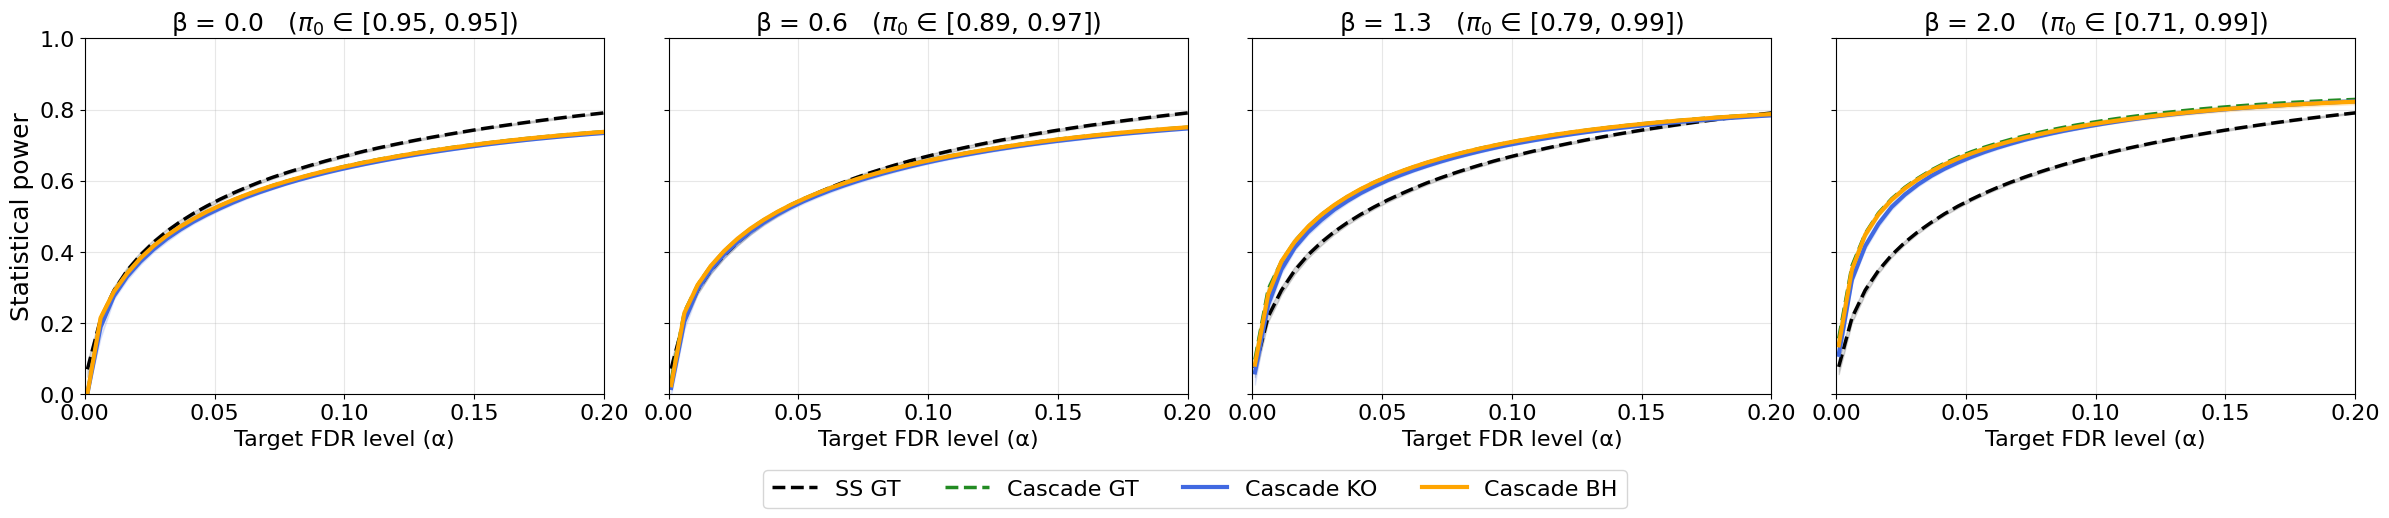

In [20]:
STYLES_H = {
    'SS GT':       ('black',       '--', 2.5),
    'Cascade GT':  ('forestgreen', '--', 2.5),
    'Cascade KO':  ('royalblue',   '-',  3.0),
    'Cascade BH':  ('orange',      '-',  3.0),
}

fig, axes = plt.subplots(1, len(BETAS_H),
                         figsize=(6 * len(BETAS_H), 5), sharey=True)

for i, beta in enumerate(BETAS_H):
    ax = axes[i]
    lo, hi = pi0_ranges_h[beta]
    for m in METHODS_H:
        c, ls, lw = STYLES_H[m]
        arr = np.array(curves_h[beta][m])
        mean = np.mean(arr, axis=0)
        std = np.std(arr, axis=0)
        ax.plot(ALPHA_GRID_H, mean, color=c, ls=ls, lw=lw)
        ax.fill_between(ALPHA_GRID_H, mean - std, mean + std,
                        color=c, alpha=0.15)
    ax.set_xlim(0, 0.20)
    ax.set_xticks([0, 0.05, 0.10, 0.15, 0.20])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, linewidth=0.8)
    ax.set_xlabel('Target FDR level (α)', fontsize=16)
    ax.set_title(f'β = {beta}   ($\pi_0$ ∈ [{lo:.2f}, {hi:.2f}])',
                 fontsize=18)
    ax.tick_params(labelsize=16)

axes[0].set_ylabel('Statistical power', fontsize=18)

handles = [plt.Line2D([], [], color=c, ls=ls, lw=lw, label=m)
           for m, (c, ls, lw) in STYLES_H.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=16,
           bbox_to_anchor=(0.5, -0.05))
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig('heterogeneity_power.png', dpi=150, bbox_inches='tight')
plt.show()